Acknowledgements: Preprocessed data from BrainLife, code written using AI tools to help.
Sedi Danku , April 2025

In [ ]:
!pip install nilearn nibabel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 23.1 MB/s eta 0:00:00


In [ ]:
from nilearn import datasets
import nibabel as nib
import numpy as np

# Load Harvard-Oxford subcortical atlas
atlas = datasets.fetch_atlas_harvard_oxford('sub-maxprob-thr25-1mm')

# preset mask for hippocampus
hippo_mask_img = atlas['maps']

# Create hippocampus binary mask (label 10 = L, 17 = R)
hippo_mask_data = hippo_mask_img.get_fdata()
hippo_mask_bin = np.isin(hippo_mask_data, [10, 17]).astype(np.uint8)

# Convert to image
hippo_mask = nib.Nifti1Image(hippo_mask_bin, hippo_mask_img.affine)

# Save it
nib.save(hippo_mask, "hippocampus_mask_MNI.nii.gz")
print("✅ Hippocampus mask saved.")


[_add_readme_to_default_data_locations] Added README.md to /root/nilearn_data

[get_dataset_dir] Dataset created in /root/nilearn_data/fsl

[fetch_single_file] Downloading data from https://www.nitrc.org/frs/download.php/9902/HarvardOxford.tgz ...

[_chunk_report_] Downloaded 16531456 of 25716861 bytes (64.3%%,    0.6s remaining)

[fetch_single_file]  ...done. (2 seconds, 0 min)

[uncompress_file] Extracting data from /root/nilearn_data/fsl/52fc6e9a44cb308dcf34a89091317d8b/HarvardOxford.tgz...

[uncompress_file] .. done.

✅ Hippocampus mask saved.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive/MyDrive/bold_outputs
!ls /content/drive/MyDrive/aparc_aseg_mgz


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
sub-01_bold.nii.gz  sub-08_bold.nii.gz	 sub-27_bold.nii.gz  sub-65_bold.nii.gz
sub-02_bold.nii.gz  sub-09_bold.nii.gz	 sub-31_bold.nii.gz  sub-66_bold.nii.gz
sub-03_bold.nii.gz  sub-11_bold.nii.gz	 sub-36_bold.nii.gz  sub-78_bold.nii.gz
sub-05_bold.nii.gz  sub-13_bold.nii.gz	 sub-48_bold.nii.gz  sub-83_bold.nii.gz
sub-06_bold.nii.gz  sub-150_bold.nii.gz  sub-49_bold.nii.gz  sub-85_bold.nii.gz
sub-07_bold.nii.gz  sub-206_bold.nii.gz  sub-51_bold.nii.gz  sub-96_bold.nii.gz
ls: cannot access '/content/drive/MyDrive/aparc_aseg_mgz': No such file or directory


In [ ]:
import os
import numpy as np
import nibabel as nib
from nilearn import masking, image, datasets
from nilearn.input_data import NiftiMasker
import matplotlib.pyplot as plt

# Folder containing BOLD files
bold_folder = "/content/drive/MyDrive/bold_outputs"


# Load the hippocampus mask
hippo_mask_img = nib.load("hippocampus_mask_MNI.nii.gz")

# Get list of all BOLD files
bold_files = sorted([f for f in os.listdir(bold_folder) if f.endswith(".nii.gz")])


print(f"Found {len(bold_files)} BOLD files.")
os.makedirs("zmaps", exist_ok=True)

# Loop through each BOLD file
for bold_file in bold_files:
    subject_id = bold_file.split(".")[0]  # e.g., sub-01
    bold_path = os.path.join(bold_folder, bold_file)
    bold_img = nib.load(bold_path)

    print(f"\n🧠 Processing {subject_id}...")

    # Resample mask to match subject's BOLD image
    hippo_mask_resampled = image.resample_to_img(hippo_mask_img, bold_img, interpolation='nearest')

    # Extract hippocampal time series (average across voxels)
    hippo_ts = masking.apply_mask(bold_img, hippo_mask_resampled).mean(axis=1)

    # Extract brain-wide voxel-wise time series
    brain_mask = masking.compute_brain_mask(bold_img)
    brain_ts = masking.apply_mask(bold_img, brain_mask)

    # Compute correlation map (voxel-wise)
    correlation_map = np.array([
        np.corrcoef(hippo_ts, voxel_ts)[0, 1] for voxel_ts in brain_ts.T
    ])

    # Fisher z-transform
    z_map = np.arctanh(correlation_map)

    # Create a masker using the brain mask
    masker = NiftiMasker(mask_img=brain_mask)
    masker.fit()  # Needed for inverse_transform

    # Inverse transform to 3D image
    z_img = masker.inverse_transform(z_map)

    # Save z-map

    zmap_filename = f"zmaps/{subject_id}_hippocampus_fc_zmap.nii.gz"
    nib.save(z_img, zmap_filename)
    print(f"✅ Saved: {zmap_filename}")


Found 24 BOLD files.

🧠 Processing sub-01_bold...


<ipython-input-5-7ee4e7c0987c>:31: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  hippo_mask_resampled = image.resample_to_img(hippo_mask_img, bold_img, interpolation='nearest')
/usr/local/lib/python3.11/dist-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


✅ Saved: zmaps/sub-01_bold_hippocampus_fc_zmap.nii.gz

🧠 Processing sub-02_bold...


<ipython-input-5-7ee4e7c0987c>:31: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  hippo_mask_resampled = image.resample_to_img(hippo_mask_img, bold_img, interpolation='nearest')
/usr/local/lib/python3.11/dist-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


✅ Saved: zmaps/sub-02_bold_hippocampus_fc_zmap.nii.gz

🧠 Processing sub-03_bold...


...

✅ Saved: zmaps/sub-83_bold_hippocampus_fc_zmap.nii.gz

🧠 Processing sub-85_bold...


<ipython-input-5-7ee4e7c0987c>:31: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  hippo_mask_resampled = image.resample_to_img(hippo_mask_img, bold_img, interpolation='nearest')
/usr/local/lib/python3.11/dist-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


✅ Saved: zmaps/sub-85_bold_hippocampus_fc_zmap.nii.gz

🧠 Processing sub-96_bold...


<ipython-input-5-7ee4e7c0987c>:31: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  hippo_mask_resampled = image.resample_to_img(hippo_mask_img, bold_img, interpolation='nearest')
/usr/local/lib/python3.11/dist-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


✅ Saved: zmaps/sub-96_bold_hippocampus_fc_zmap.nii.gz


In [ ]:
mgz_folder = "/content/drive/MyDrive/aparc+aseg"
nii_folder = "/content/aparc_segmentations"
os.makedirs(nii_folder, exist_ok=True)

converted = 0

for fname in sorted(os.listdir(mgz_folder)):
    if fname.endswith(".mgz"):
        subject_id = fname.split("_")[0]  # e.g., sub-01 from sub-01_aparc+aseg.mgz
        mgz_path = os.path.join(mgz_folder, fname)
        nii_path = os.path.join(nii_folder, f"{subject_id}_aparc+aseg.nii.gz")

        try:
            img = nib.load(mgz_path)
            nib.save(img, nii_path)
            print(f"✅ Converted {fname} → {nii_path}")
            converted += 1
        except Exception as e:
            print(f"❌ Failed to convert {fname}: {e}")

print(f"\n🎉 Done! Converted {converted} files into {nii_folder}")


✅ Converted sub-01_aparc+aseg.mgz → /content/aparc_segmentations/sub-01_aparc+aseg.nii.gz
✅ Converted sub-02_aparc+aseg.mgz → /content/aparc_segmentations/sub-02_aparc+aseg.nii.gz
✅ Converted sub-03_aparc+aseg.mgz → /content/aparc_segmentations/sub-03_aparc+aseg.nii.gz
✅ Converted sub-05_aparc+aseg.mgz → /content/aparc_segmentations/sub-05_aparc+aseg.nii.gz
✅ Converted sub-06_aparc+aseg.mgz → /content/aparc_segmentations/sub-06_aparc+aseg.nii.gz
✅ Converted sub-07_aparc+aseg.mgz → /content/aparc_segmentations/sub-07_aparc+aseg.nii.gz
✅ Converted sub-08_aparc+aseg.mgz → /content/aparc_segmentations/sub-08_aparc+aseg.nii.gz
✅ Converted sub-09_aparc+aseg.mgz → /content/aparc_segmentations/sub-09_aparc+aseg.nii.gz
✅ Converted sub-11_aparc+aseg.mgz → /content/aparc_segmentations/sub-11_aparc+aseg.nii.gz
✅ Converted sub-13_aparc+aseg.mgz → /content/aparc_segmentations/sub-13_aparc+aseg.nii.gz
✅ Converted sub-150_aparc+aseg.mgz → /content/aparc_segmentations/sub-150_aparc+aseg.nii.gz
✅ Conver

In [ ]:
import os
import nibabel as nib
import numpy as np
import pandas as pd
from nilearn.image import resample_to_img

# --- Paths ---
zmap_folder = "/content/zmaps"
aparc_folder = "/content/aparc_segmentations"
output_csv = "roi_zscores.csv"

# --- ROI Labels ---
roi_labels = {
    17: "L_Hippocampus",
    53: "R_Hippocampus",
    1006: "L_Entorhinal",
    2006: "R_Entorhinal",
    1009: "L_InferiorParietal",
    2009: "R_InferiorParietal",
    1025: "L_Precuneus",
    2025: "R_Precuneus",
    2030: "R_PCC",
    1030: "L_SuperiorTemporal",
    1013: "L_MedialOFC",
    2013: "R_MedialOFC"
}

# --- Load atlas ---
# atlas_img = nib.load(atlas_path)
# atlas_data = atlas_img.get_fdata()

# --- Extract from all z-maps ---
data_rows = []

for zfile in sorted(os.listdir(zmap_folder)):
    if zfile.endswith(".nii.gz"):
        subject_id = zfile.split("_")[0]  # e.g., sub-01
        z_path = os.path.join(zmap_folder, zfile)
        aparc_path = os.path.join(aparc_folder, f"{subject_id}_aparc+aseg.nii.gz")
        z_img = nib.load(z_path)
        z_data = z_img.get_fdata()
        aparc_img = nib.load(aparc_path)


        # Resample aparc to match the z-map shape and affine
        aparc_resampled = resample_to_img(aparc_img, z_img, interpolation='nearest')
        aparc_data = aparc_resampled.get_fdata()


        row = {"subject_id": subject_id}

        for label_val, roi_name in roi_labels.items():
            roi_mask = (aparc_data == label_val)
            roi_vals = z_data[roi_mask]

            # Filter out NaNs
            roi_vals = roi_vals[~np.isnan(roi_vals)]

            row[roi_name] = np.mean(roi_vals) if len(roi_vals) > 0 else np.nan

        data_rows.append(row)
        print(f"✅ Extracted: {subject_id}")

# --- Save to CSV ---
df = pd.DataFrame(data_rows)
df.to_csv(output_csv, index=False)
print(f"\n📄 ROI z-score table saved to: {output_csv}")


<ipython-input-12-2b8c3a58be7b>:46: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  aparc_resampled = resample_to_img(aparc_img, z_img, interpolation='nearest')
/usr/local/lib/python3.11/dist-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


✅ Extracted: sub-01


<ipython-input-12-2b8c3a58be7b>:46: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  aparc_resampled = resample_to_img(aparc_img, z_img, interpolation='nearest')
/usr/local/lib/python3.11/dist-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


✅ Extracted: sub-02


<ipython-input-12-2b8c3a58be7b>:46: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  aparc_resampled = resample_to_img(aparc_img, z_img, interpolation='nearest')
/usr/local/lib/python3.11/dist-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


...

✅ Extracted: sub-83


<ipython-input-12-2b8c3a58be7b>:46: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  aparc_resampled = resample_to_img(aparc_img, z_img, interpolation='nearest')
/usr/local/lib/python3.11/dist-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


✅ Extracted: sub-85


<ipython-input-12-2b8c3a58be7b>:46: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  aparc_resampled = resample_to_img(aparc_img, z_img, interpolation='nearest')
/usr/local/lib/python3.11/dist-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


✅ Extracted: sub-96

📄 ROI z-score table saved to: roi_zscores.csv


Calculated fischer-z correlation between hippocampus time series and voxels to evaluate the correlation between hippocampus and various regions.

🧠 Validating: sub-01


<ipython-input-17-9691cf442515>:36: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  aparc_resampled = image.resample_to_img(aparc_img, z_img, interpolation='nearest')
/usr/local/lib/python3.11/dist-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(
/usr/local/lib/python3.11/dist-packages/nilearn/plotting/img_plotting.py:1416: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),
/usr/local/lib/python3.11/dist-packages/nilearn/plotting/img_plotting.py:559: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  data = saf

🧠 Validating: sub-02


/usr/local/lib/python3.11/dist-packages/nilearn/plotting/img_plotting.py:1416: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),
/usr/local/lib/python3.11/dist-packages/nilearn/plotting/img_plotting.py:559: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  data = safe_get_data(anat_img, ensure_finite=True)


🧠 Validating: sub-03


...

<ipython-input-17-9691cf442515>:36: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  aparc_resampled = image.resample_to_img(aparc_img, z_img, interpolation='nearest')
/usr/local/lib/python3.11/dist-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(
/usr/local/lib/python3.11/dist-packages/nilearn/plotting/img_plotting.py:1416: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),
/usr/local/lib/python3.11/dist-packages/nilearn/plotting/img_plotting.py:559: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  data = saf

🧠 Validating: sub-85


<ipython-input-17-9691cf442515>:36: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  aparc_resampled = image.resample_to_img(aparc_img, z_img, interpolation='nearest')
/usr/local/lib/python3.11/dist-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(
/usr/local/lib/python3.11/dist-packages/nilearn/plotting/img_plotting.py:1416: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),
/usr/local/lib/python3.11/dist-packages/nilearn/plotting/img_plotting.py:559: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  data = saf

🧠 Validating: sub-96


<ipython-input-17-9691cf442515>:36: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  aparc_resampled = image.resample_to_img(aparc_img, z_img, interpolation='nearest')
/usr/local/lib/python3.11/dist-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(
/usr/local/lib/python3.11/dist-packages/nilearn/plotting/img_plotting.py:1416: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),
/usr/local/lib/python3.11/dist-packages/nilearn/plotting/img_plotting.py:559: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  data = saf

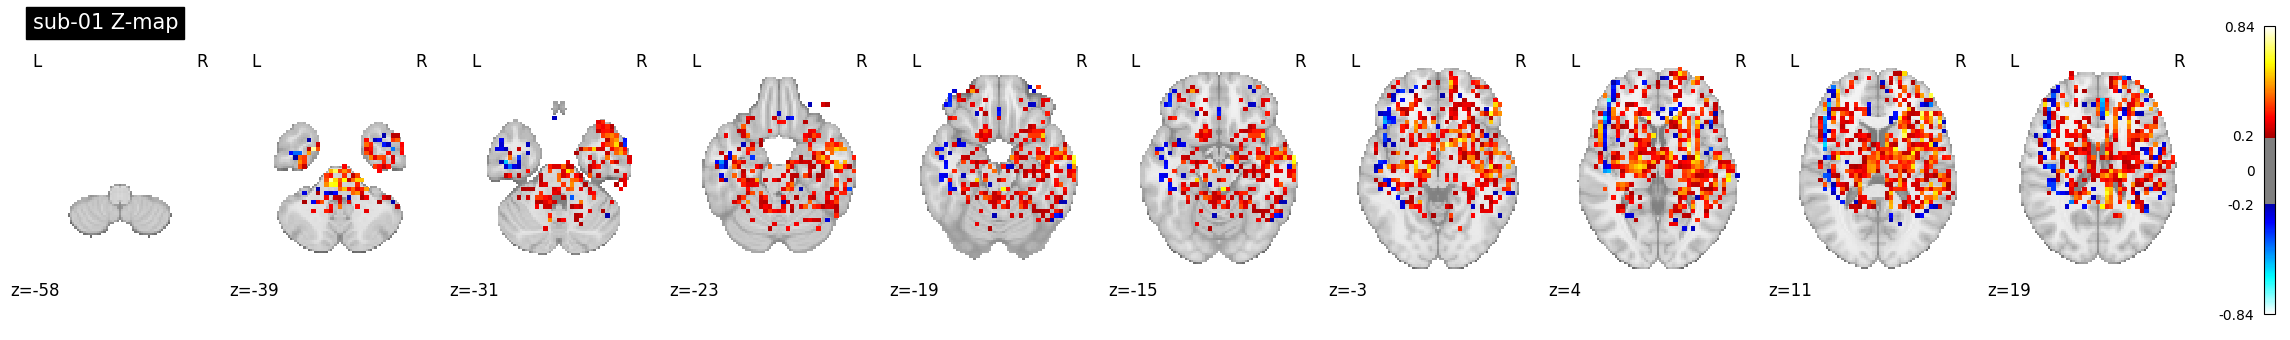

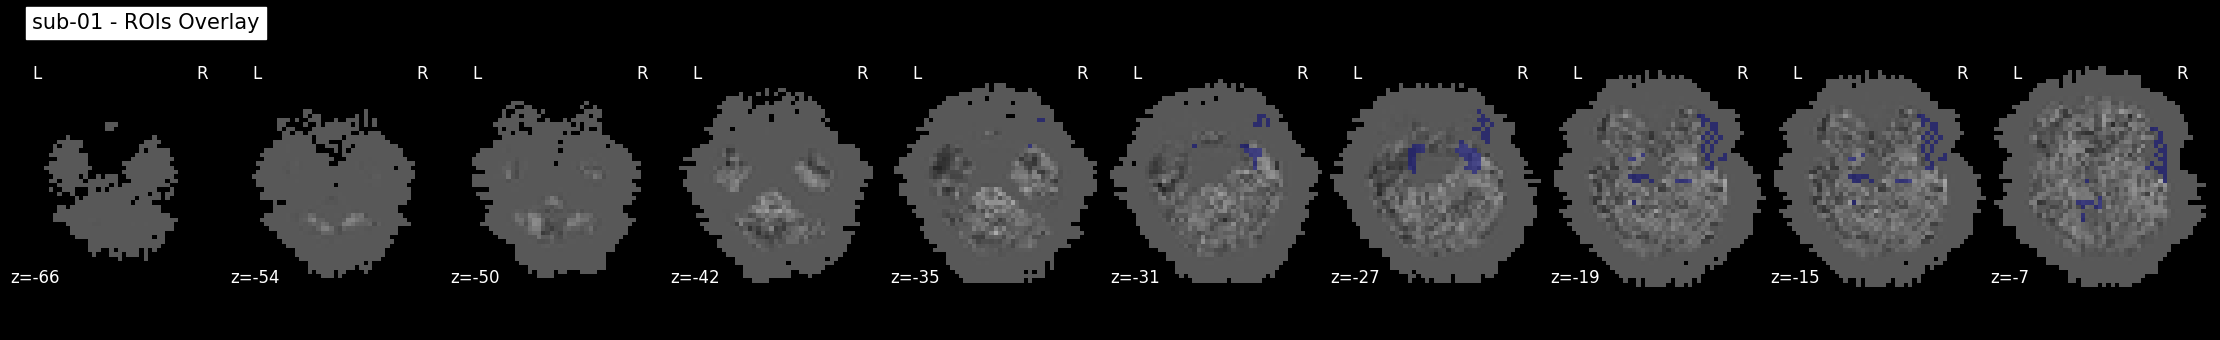

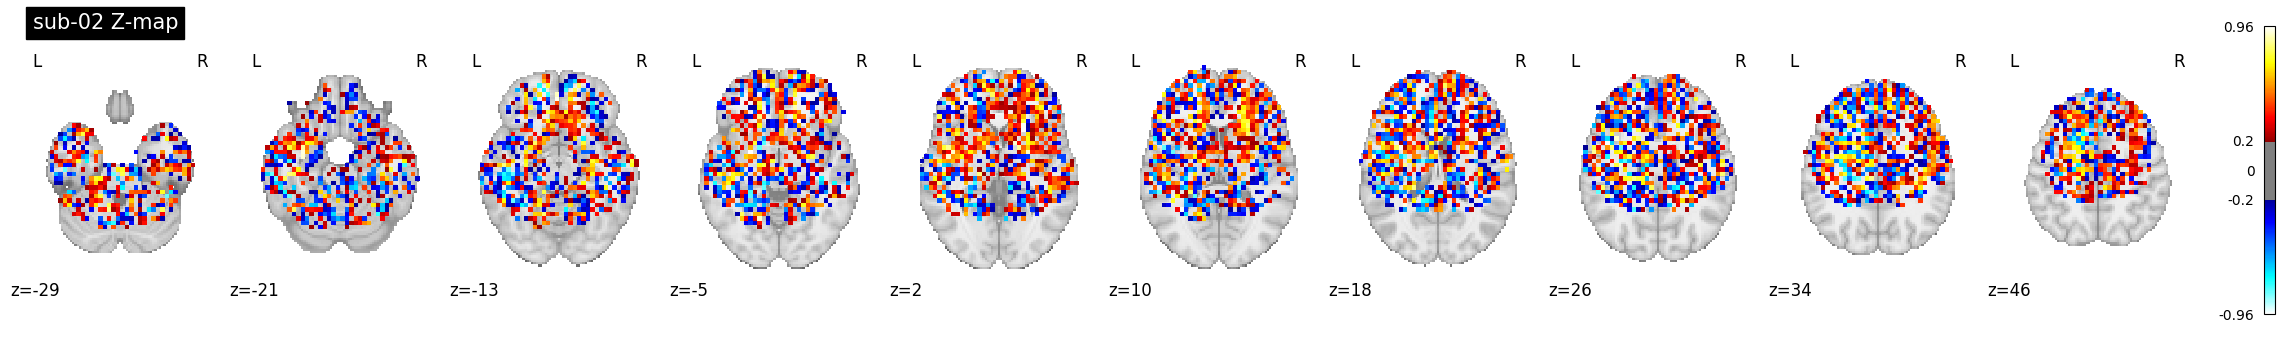

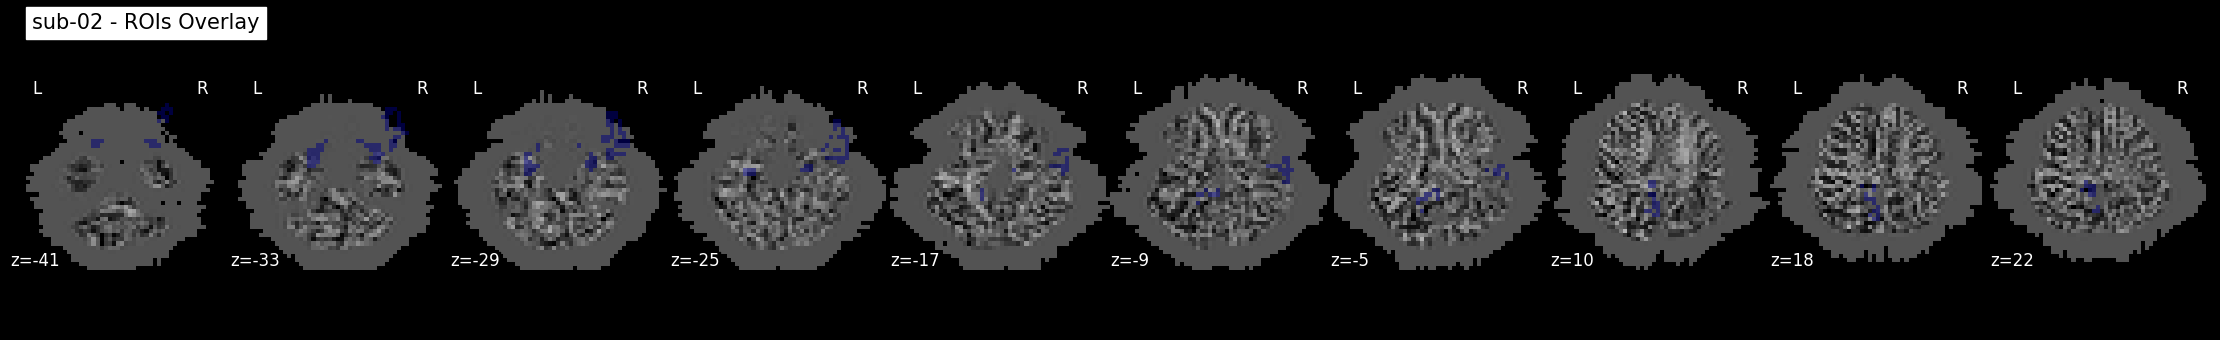

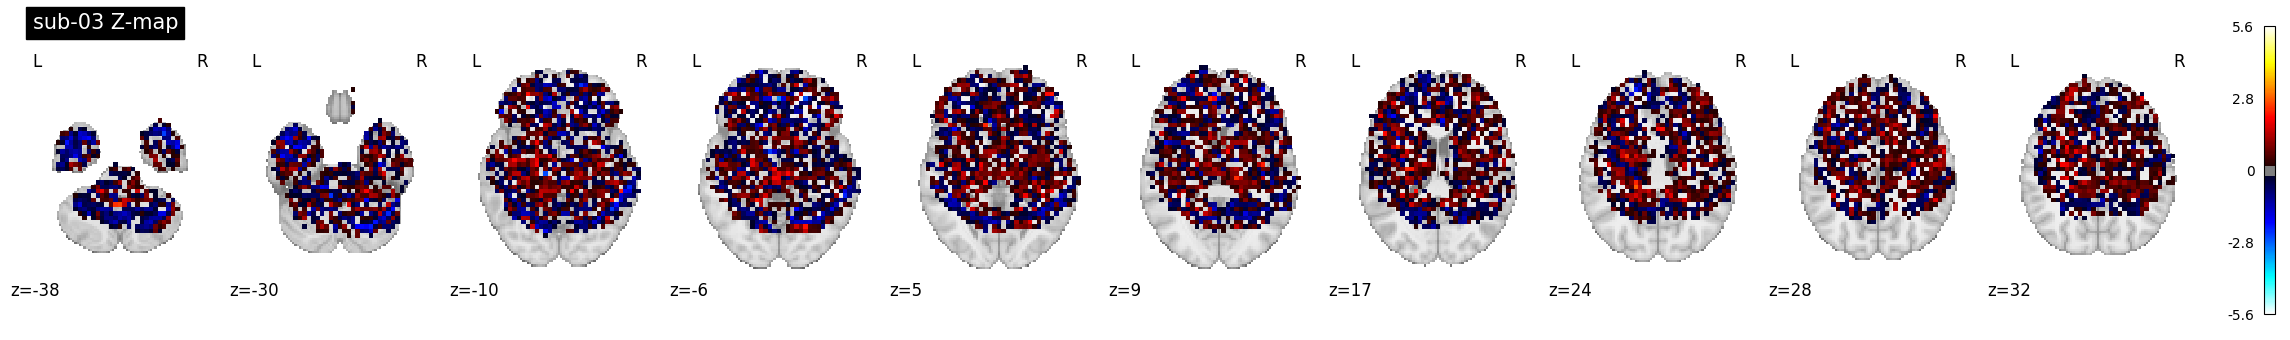

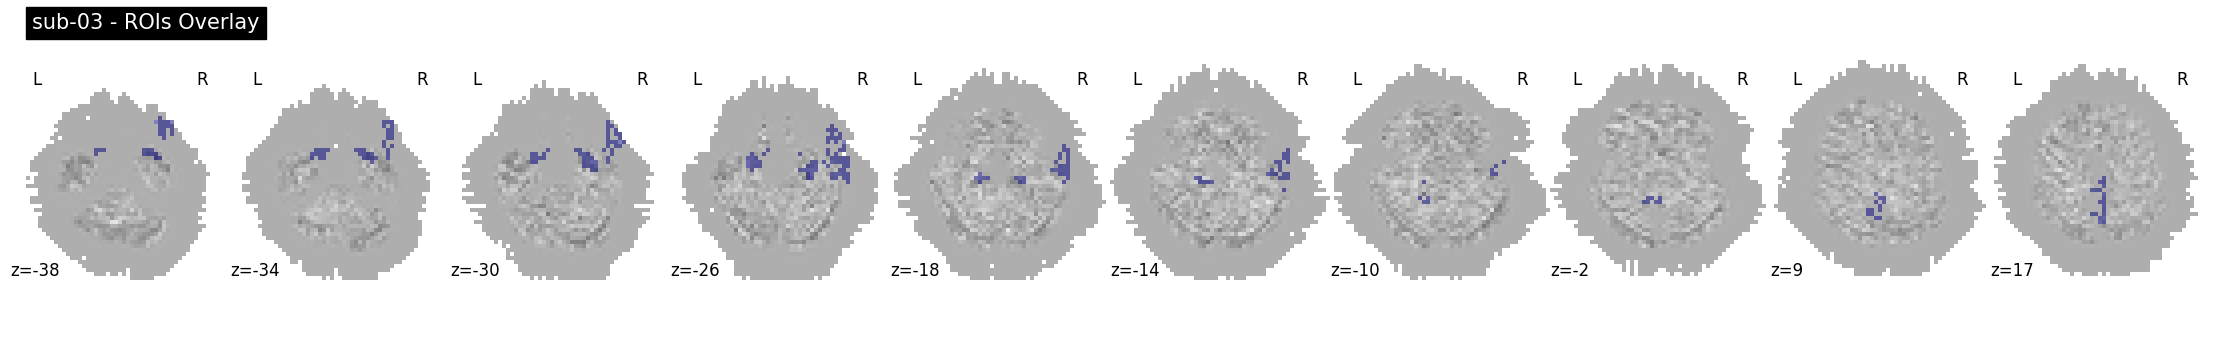

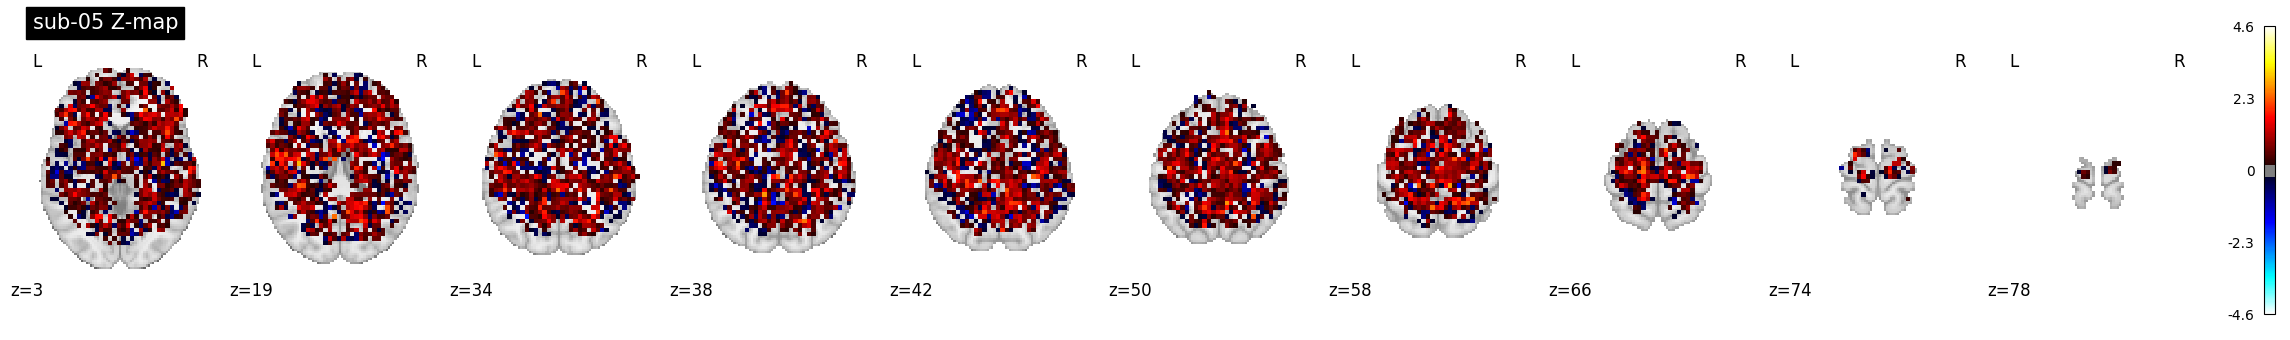

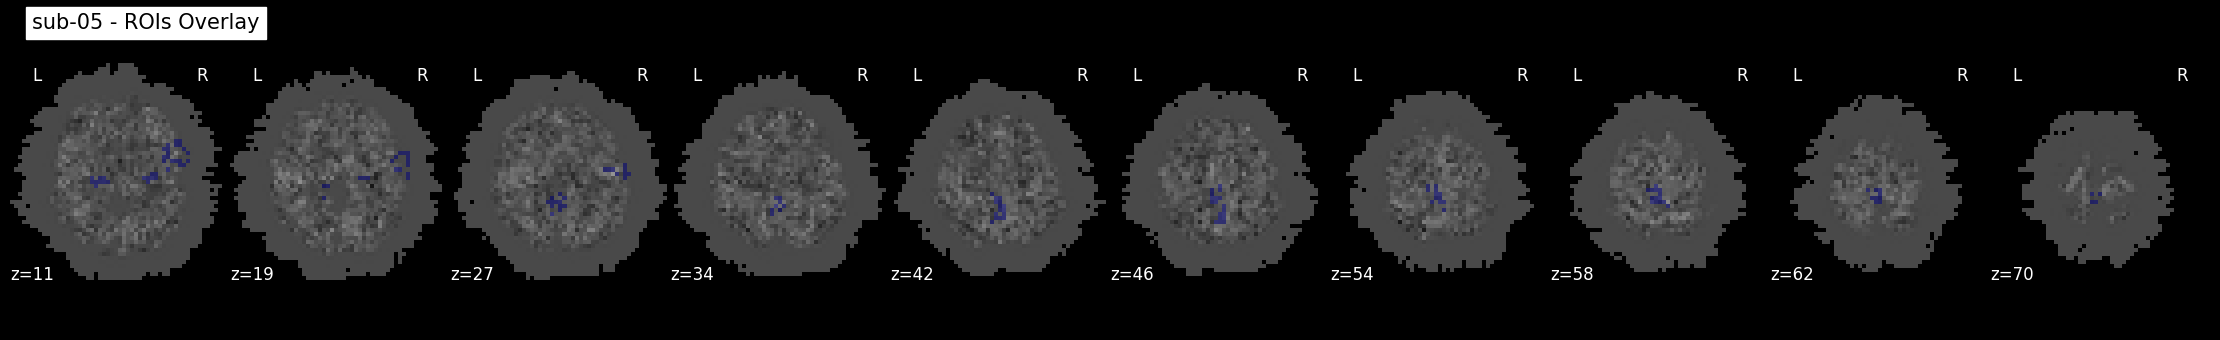

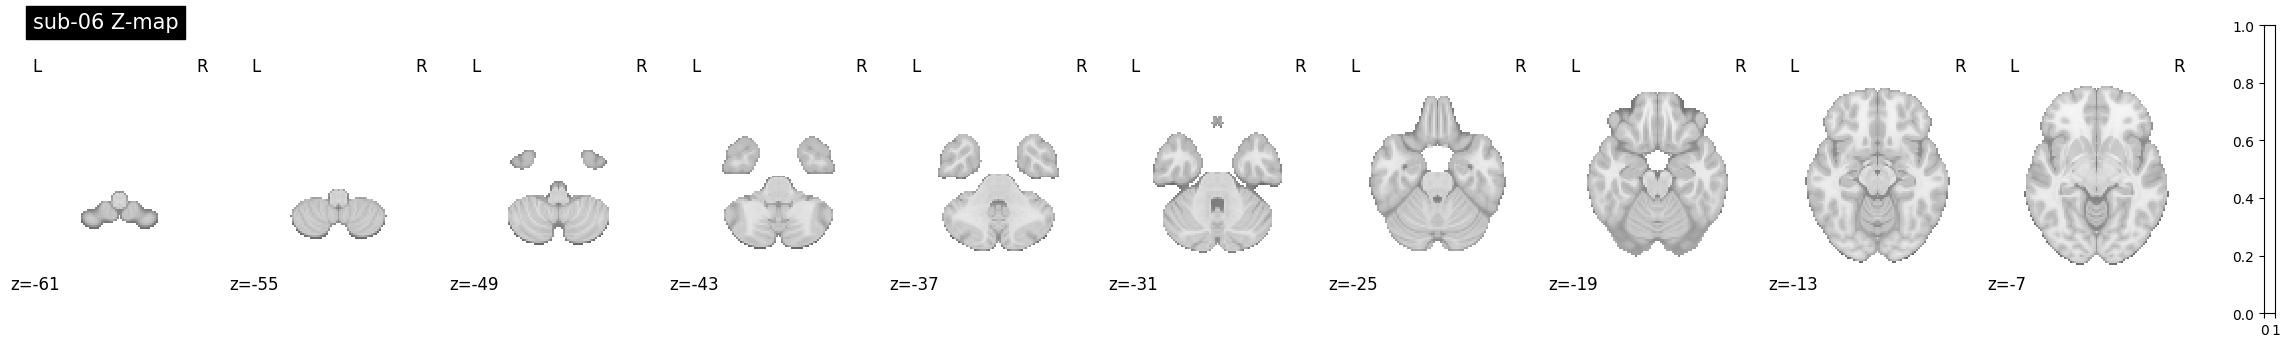

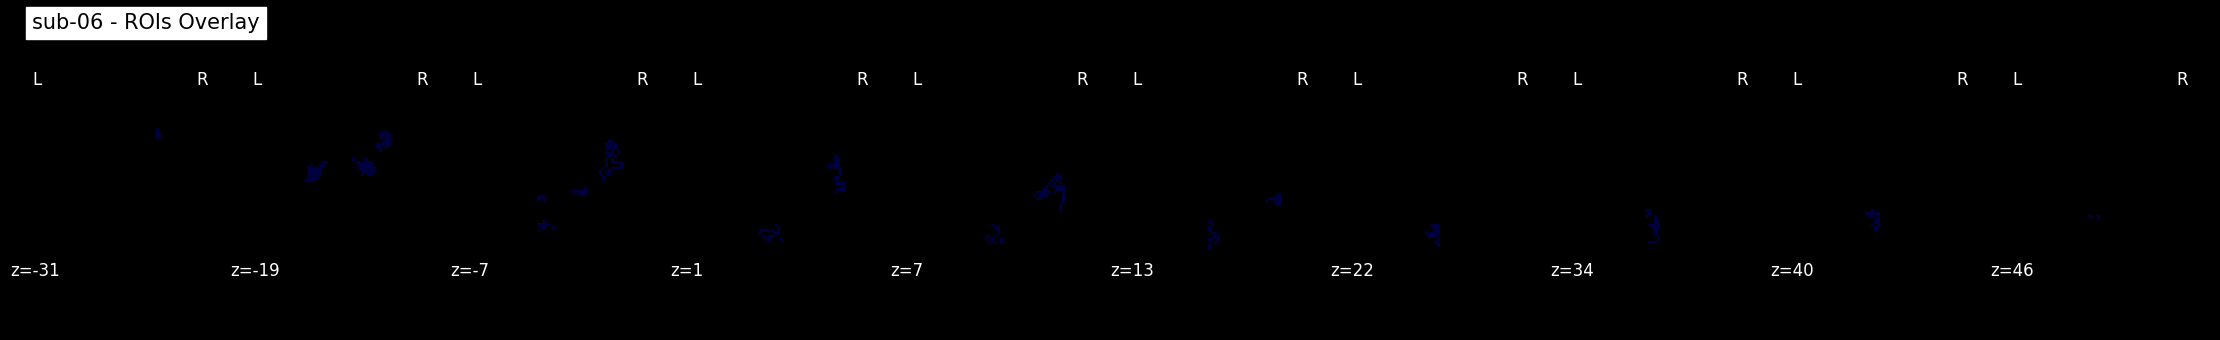

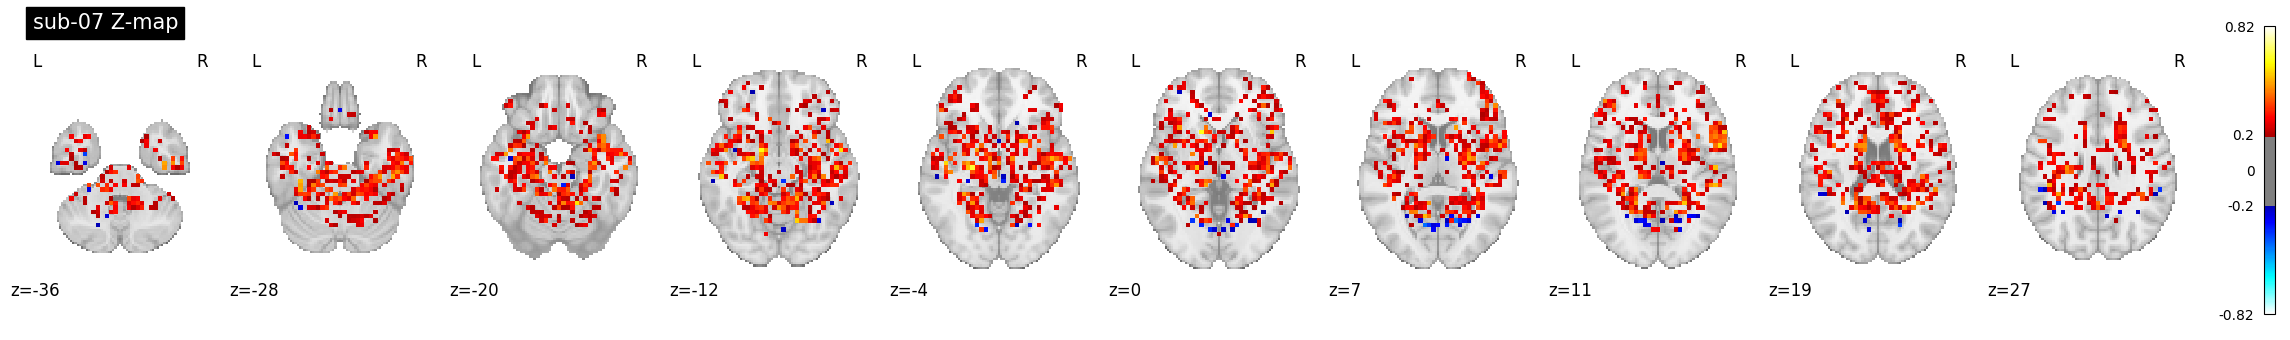

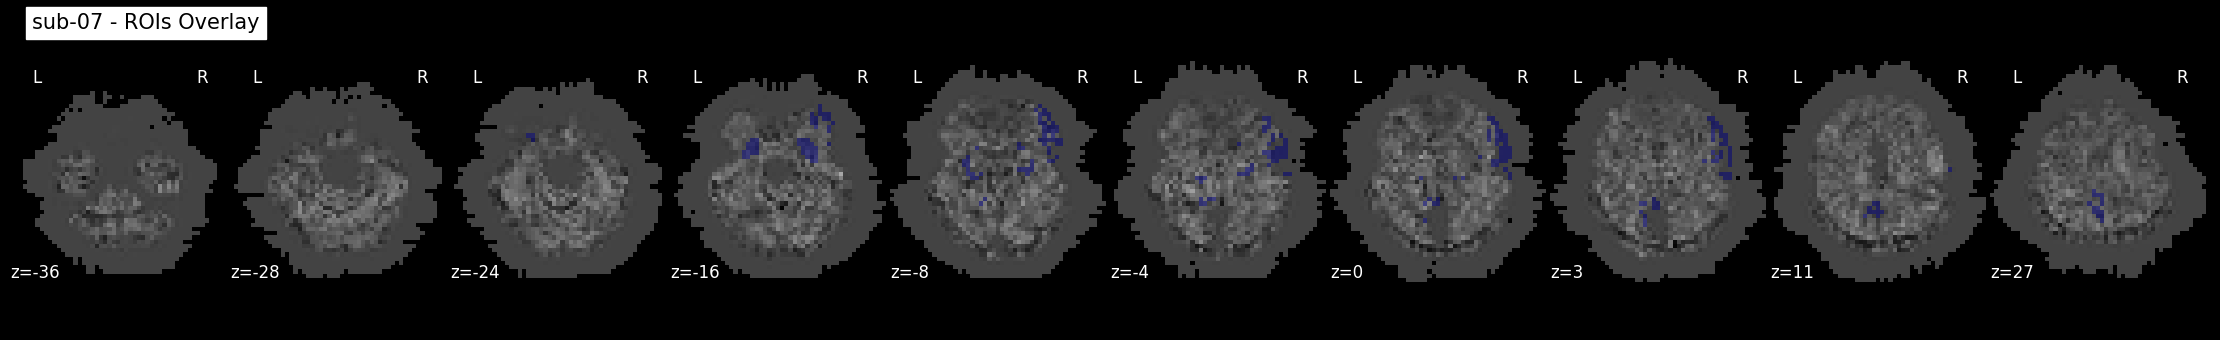

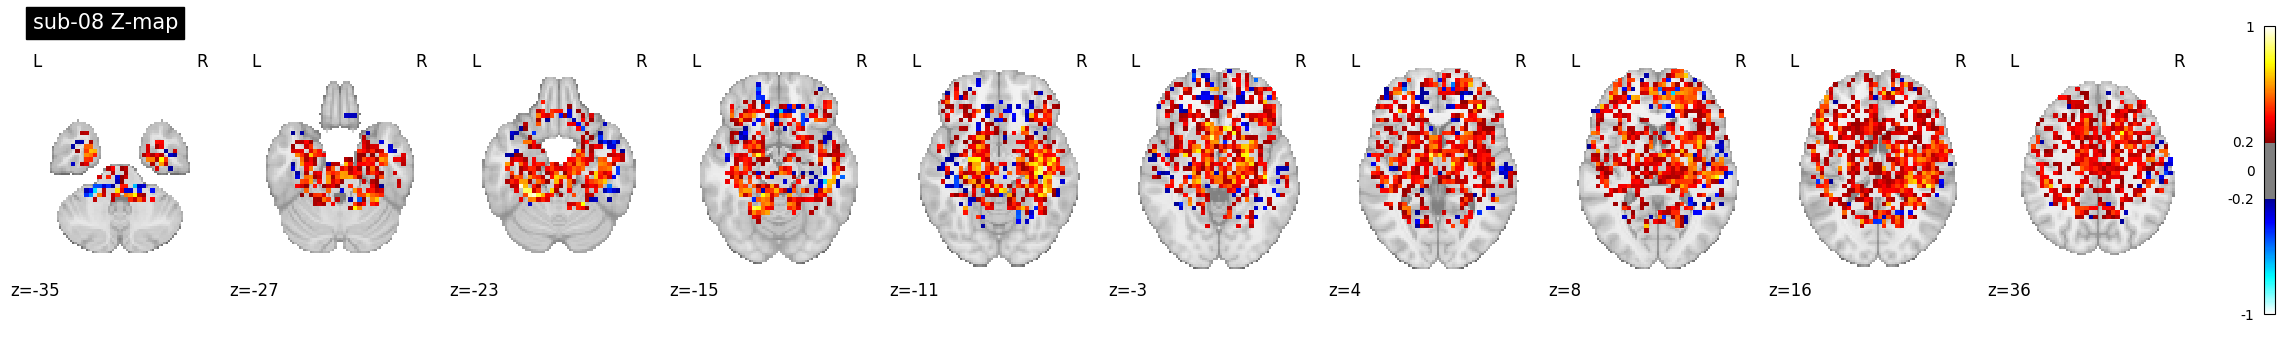

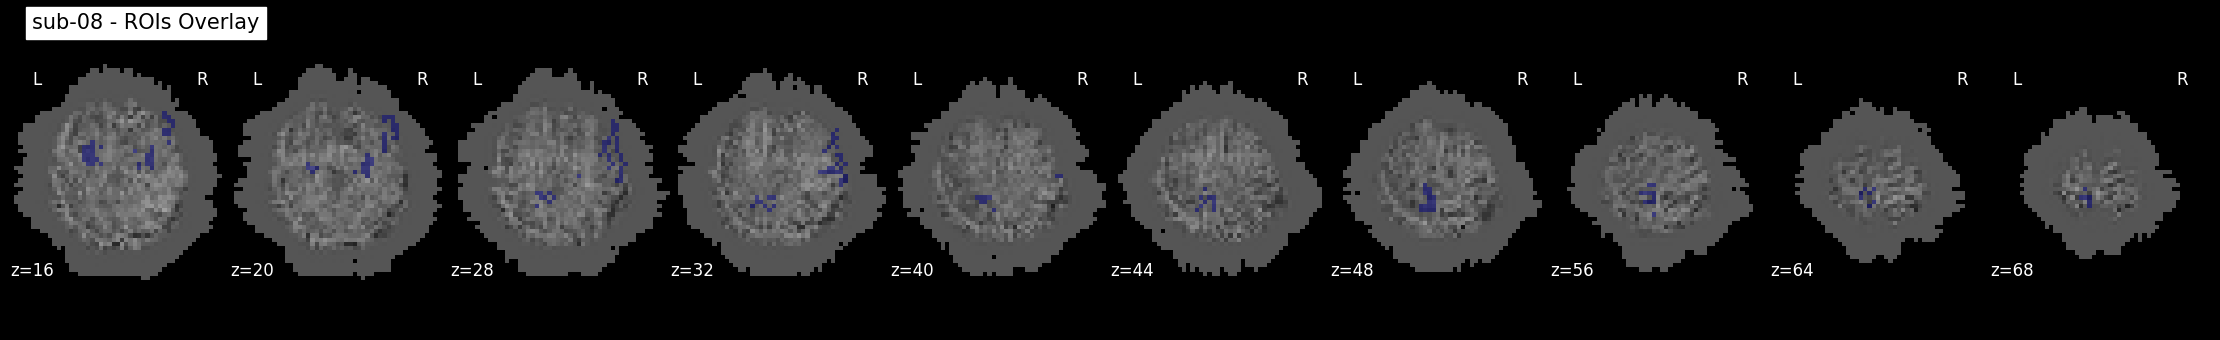

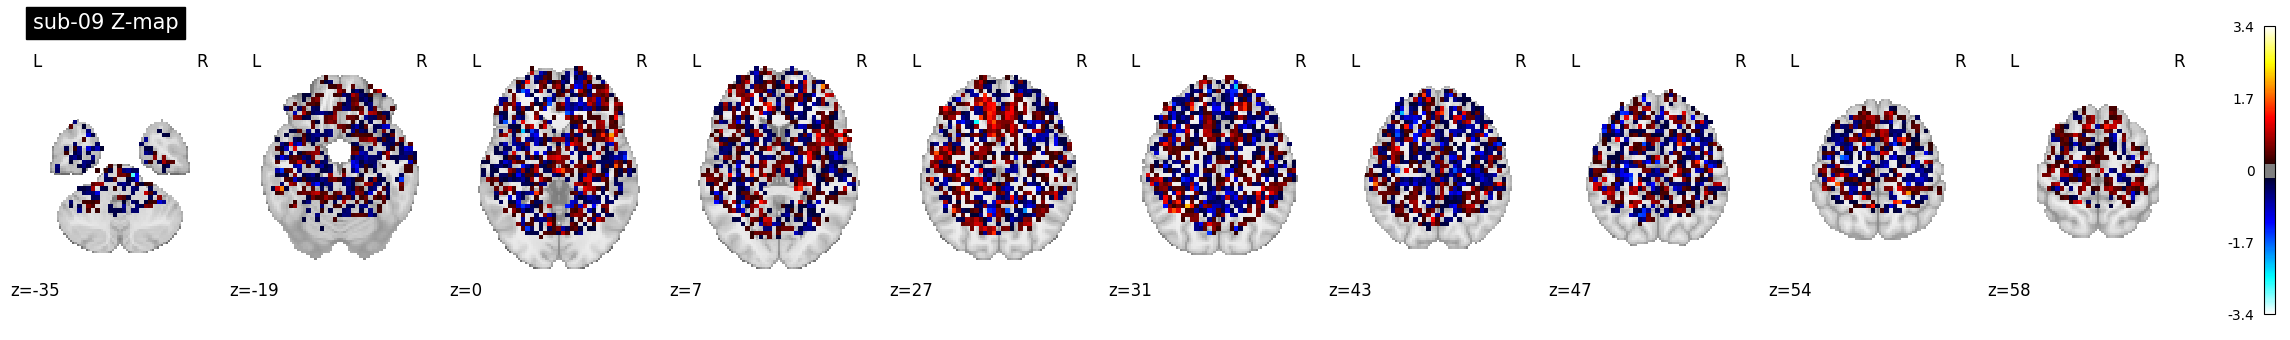

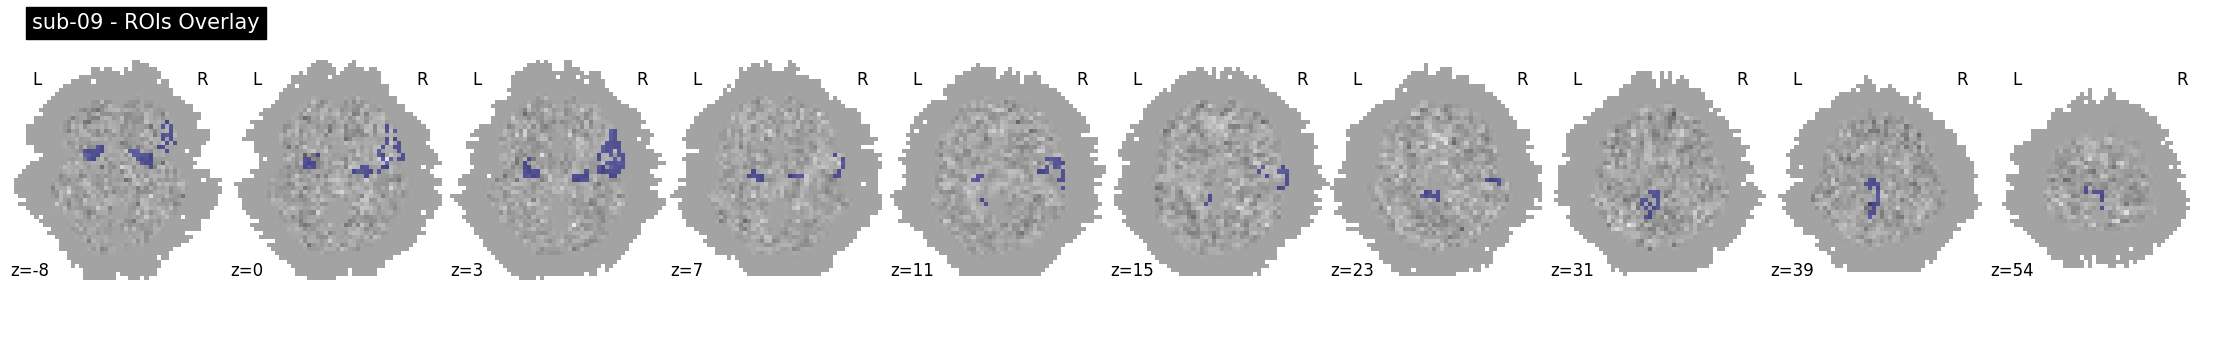

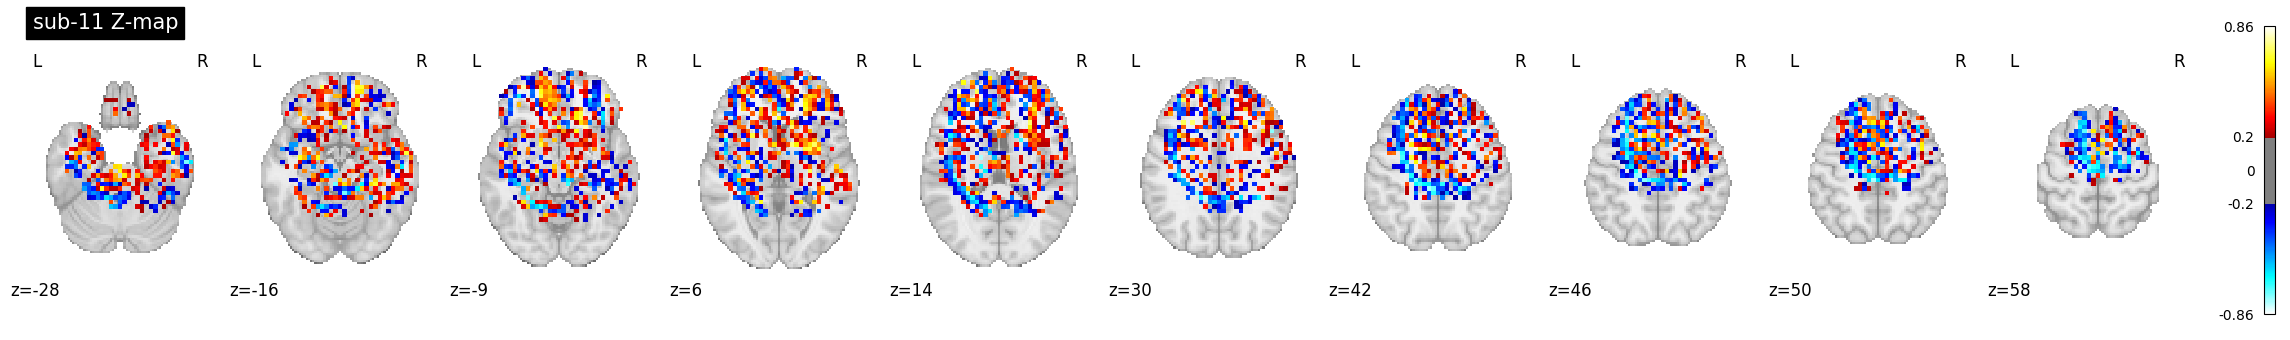

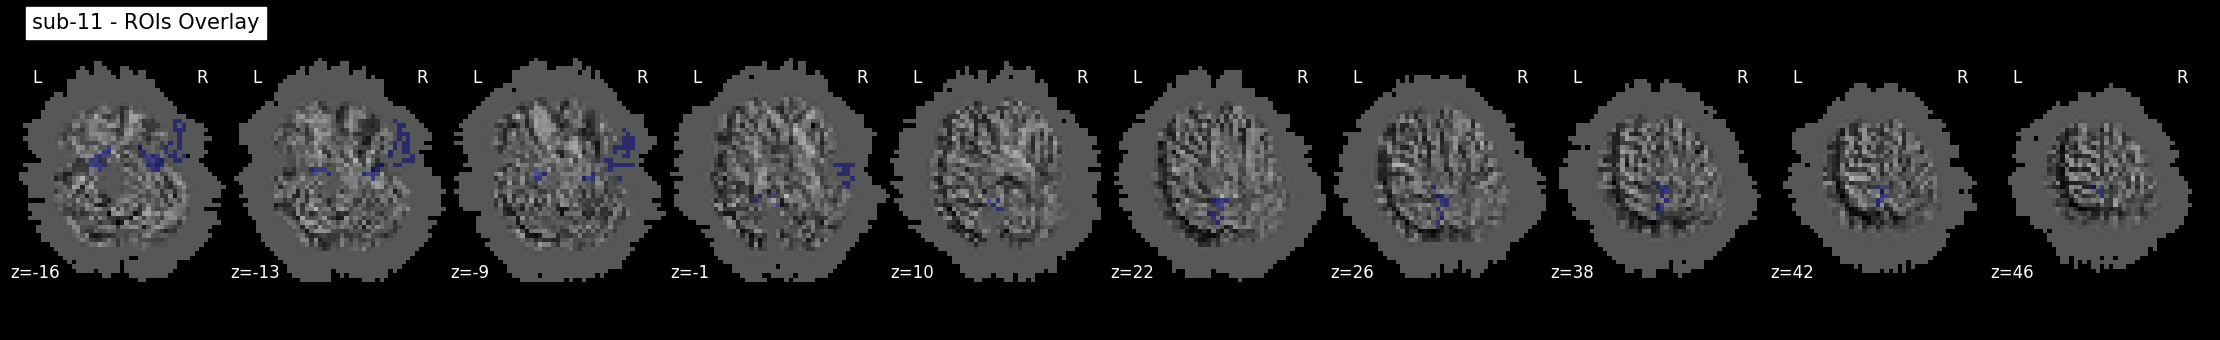

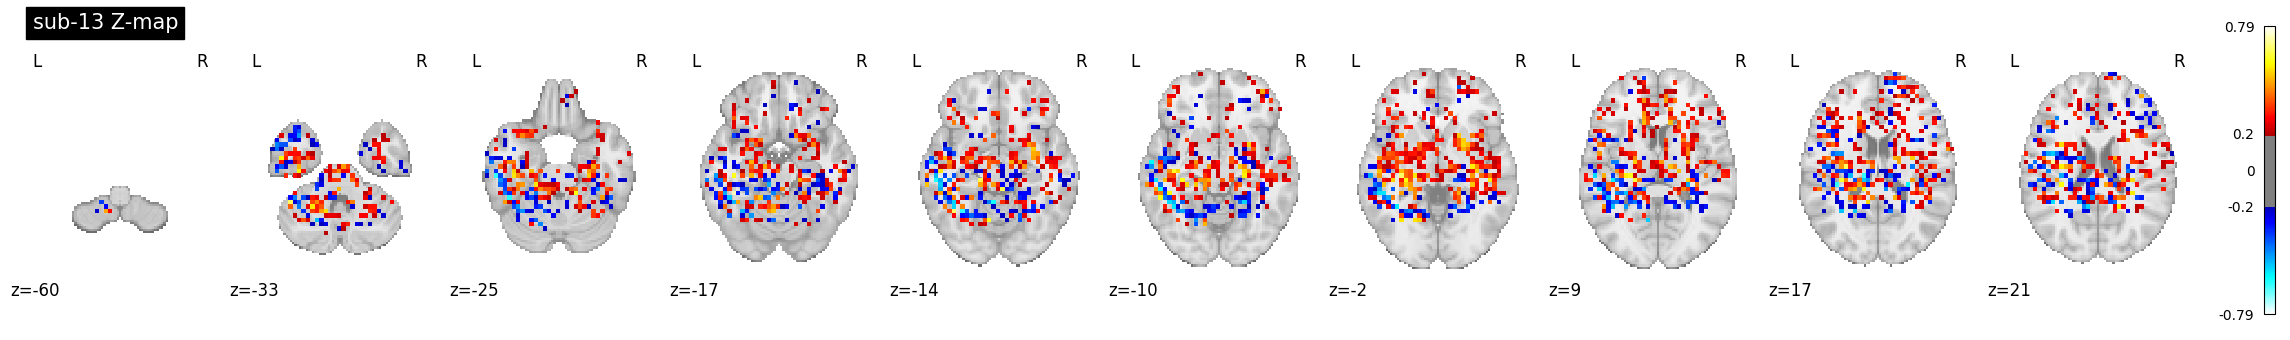

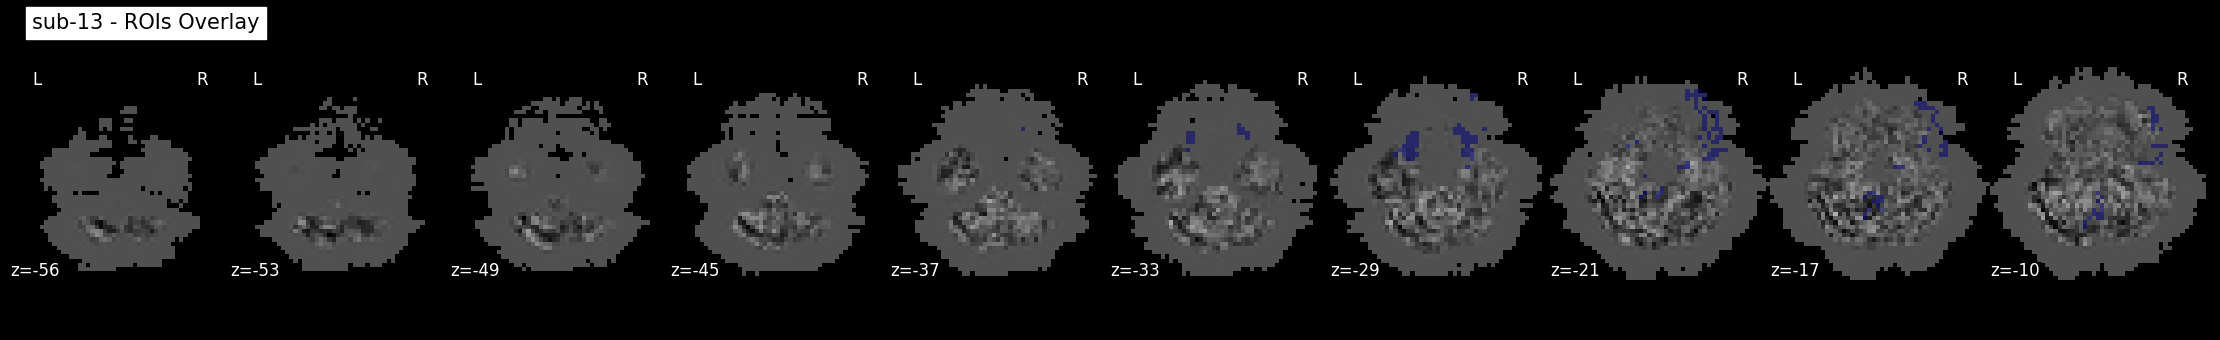

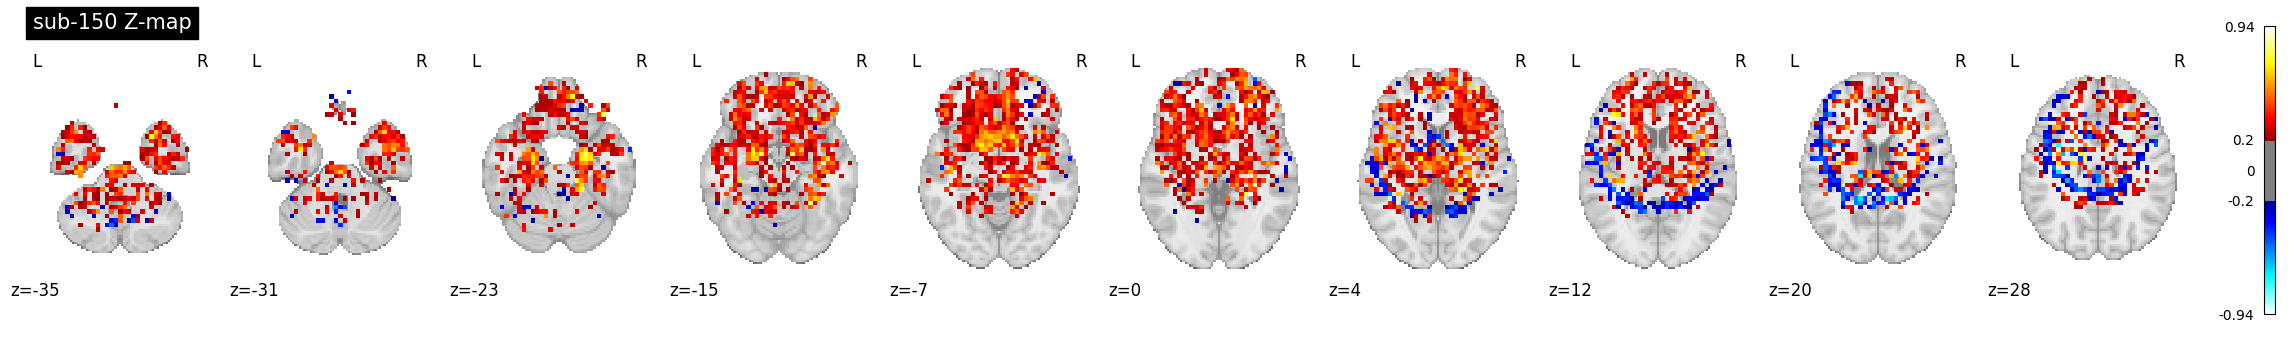

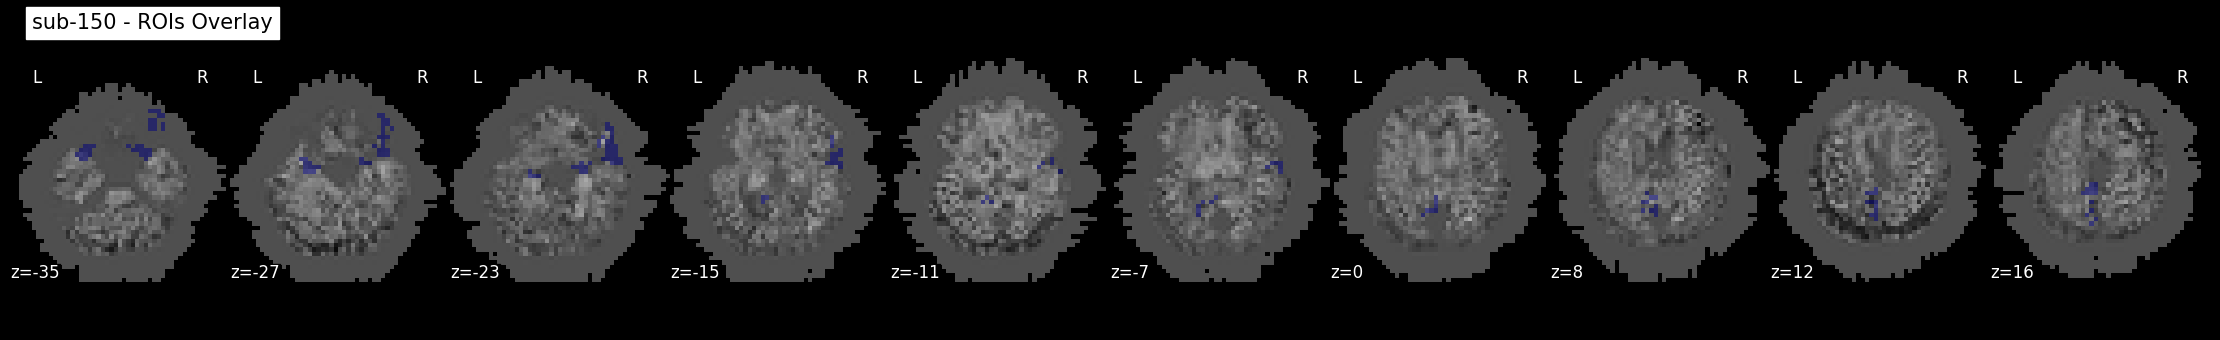

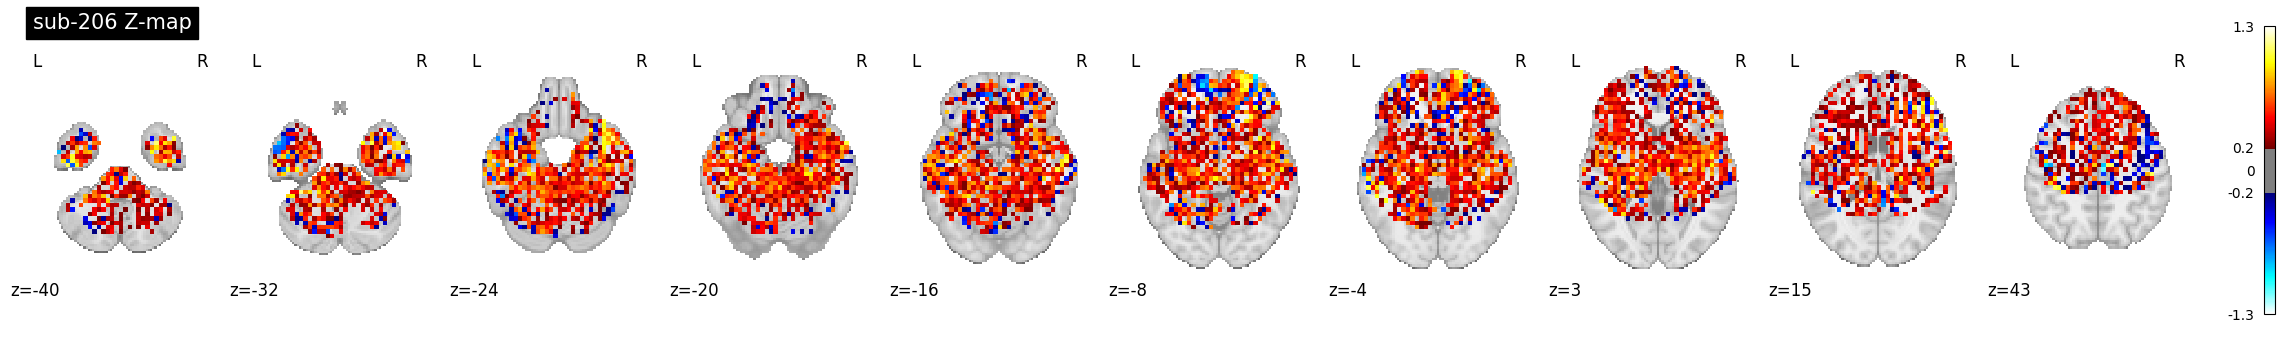

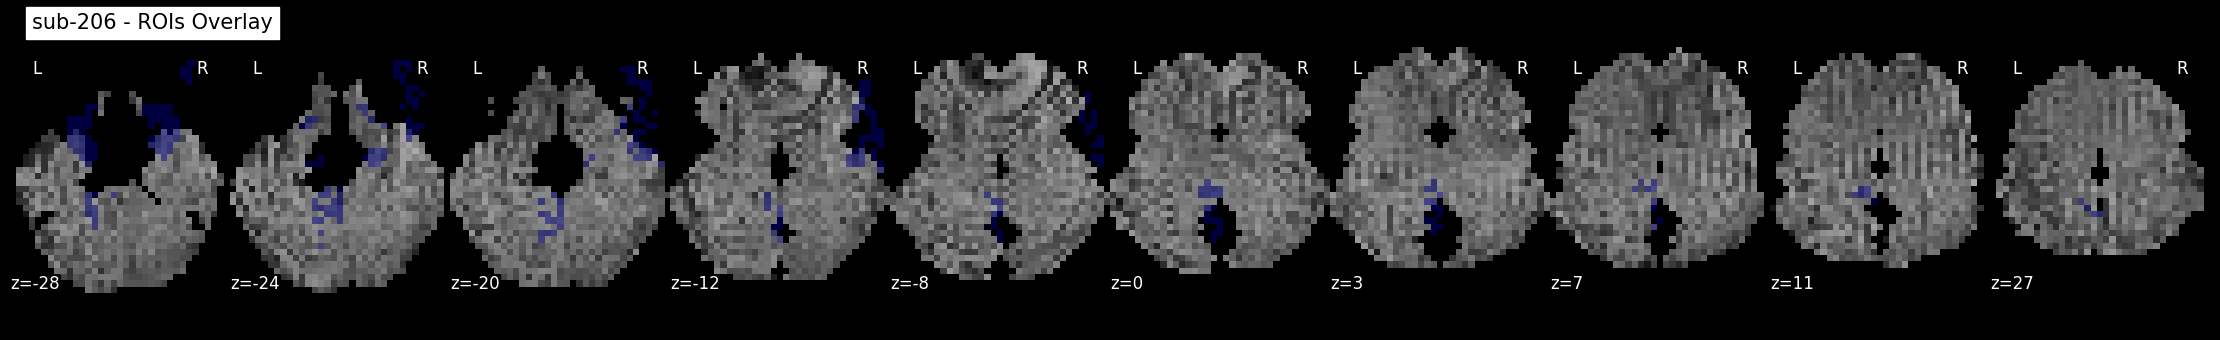

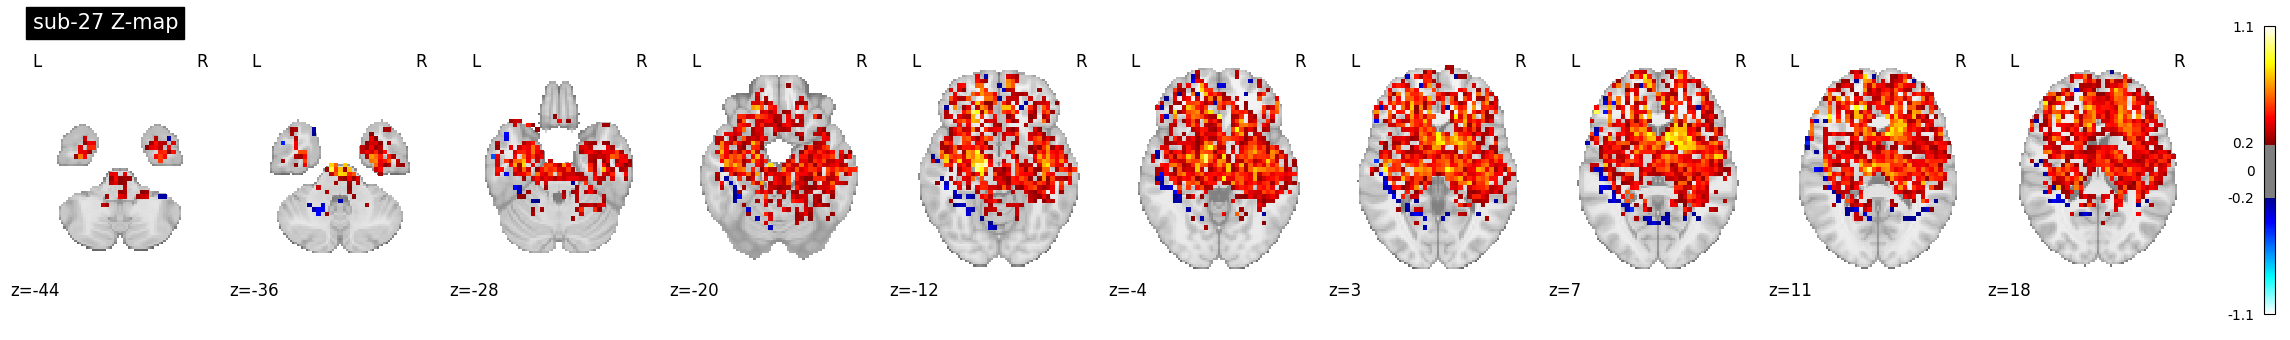

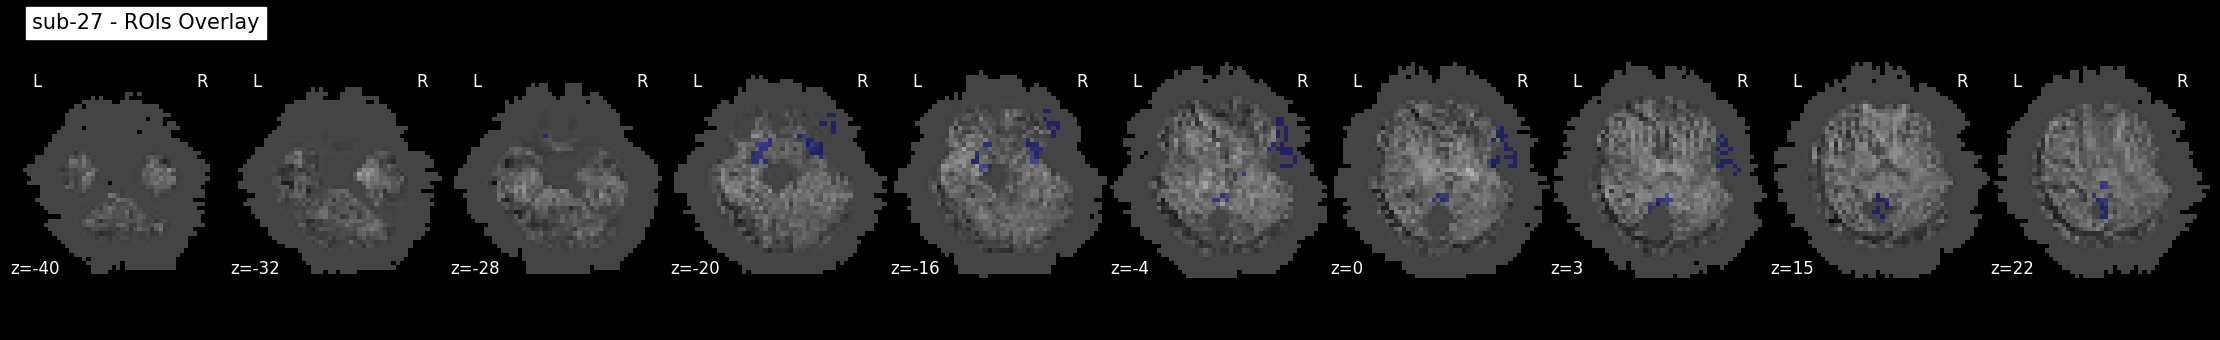

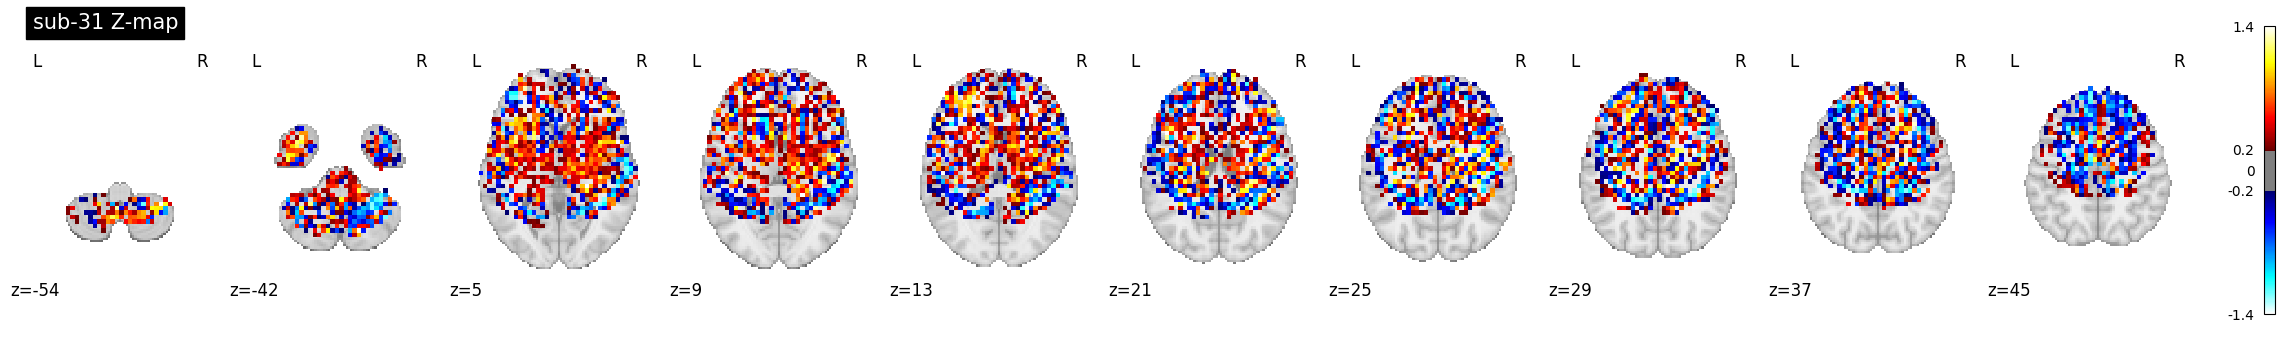

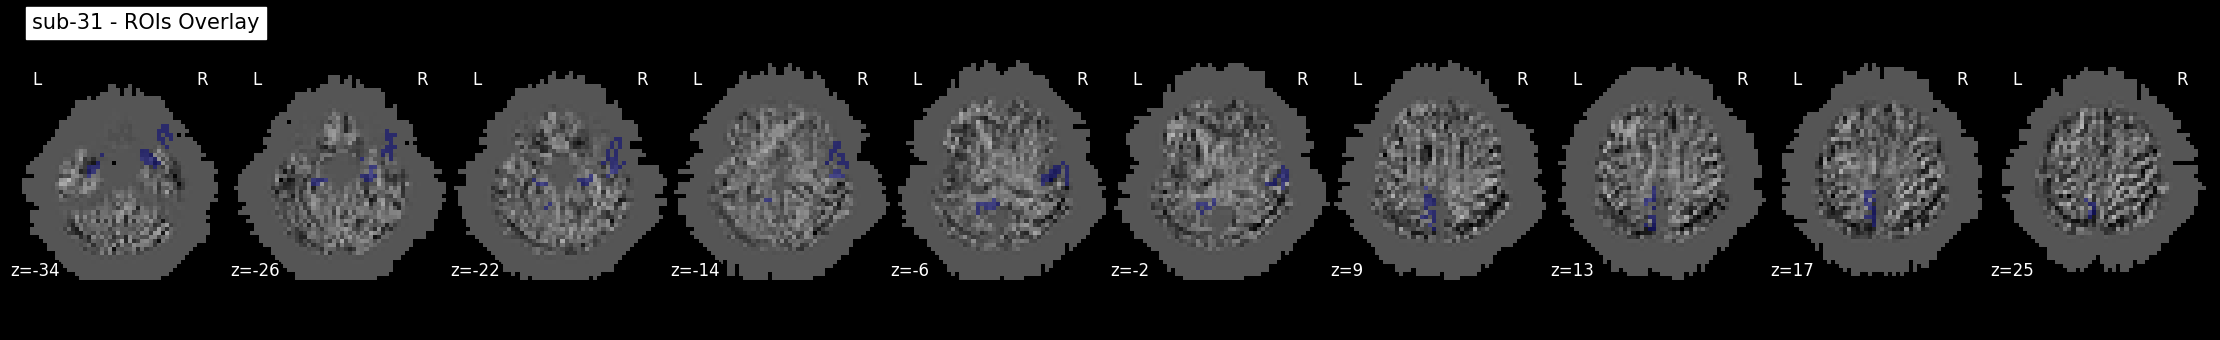

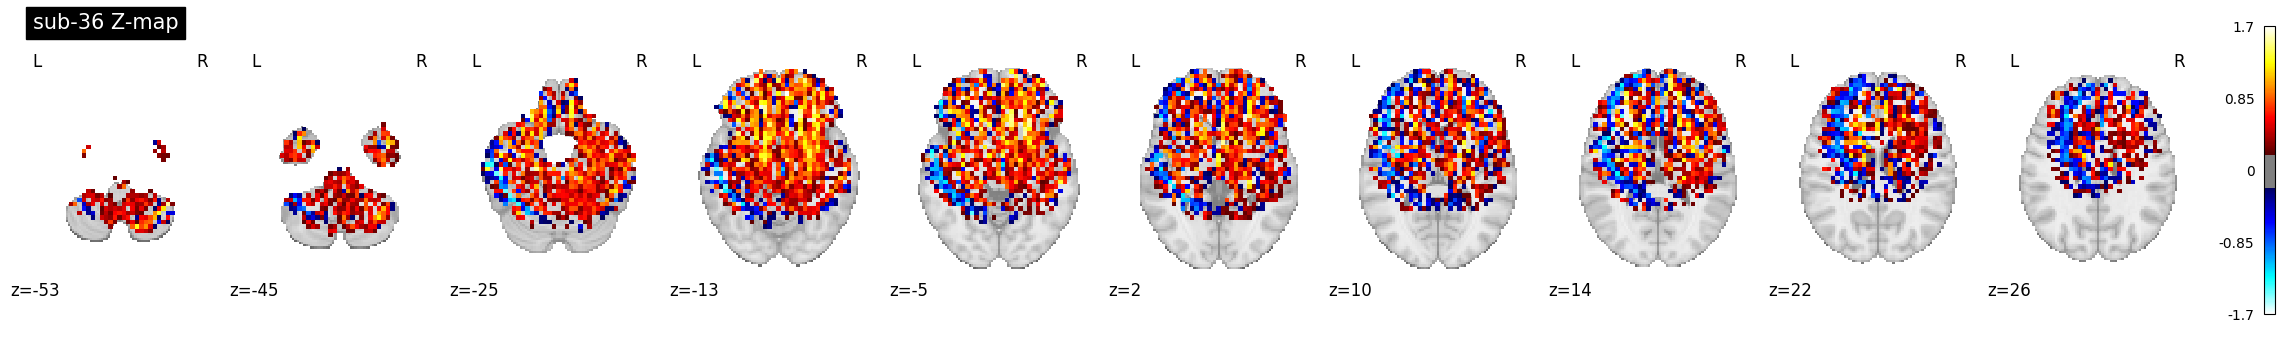

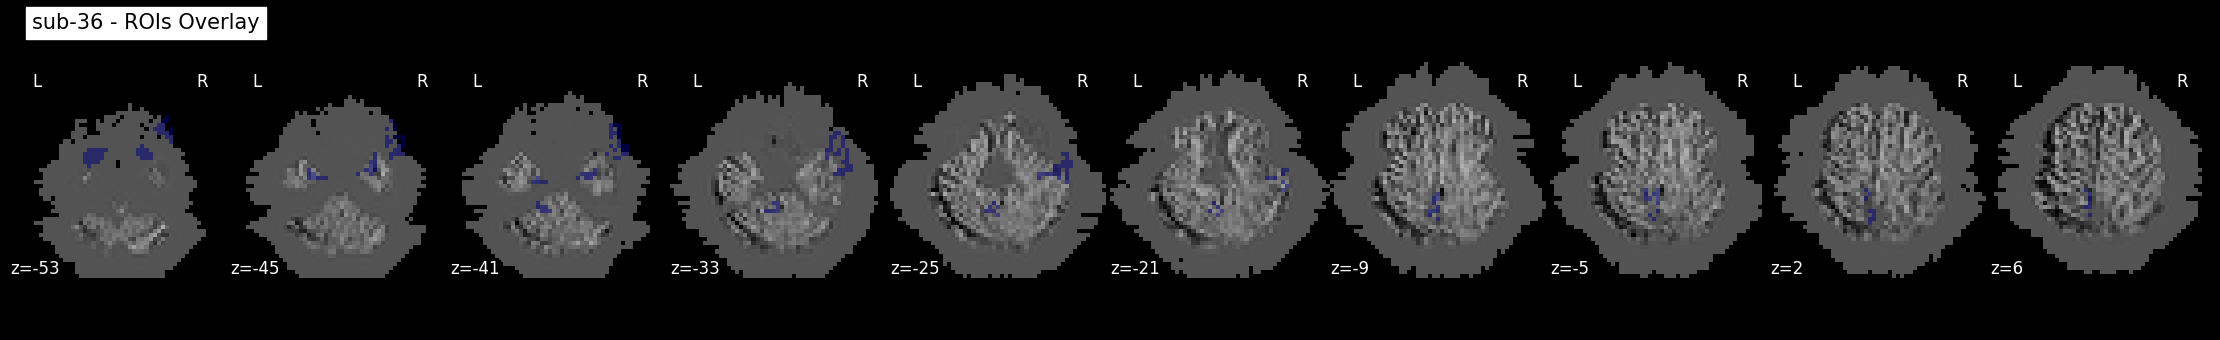

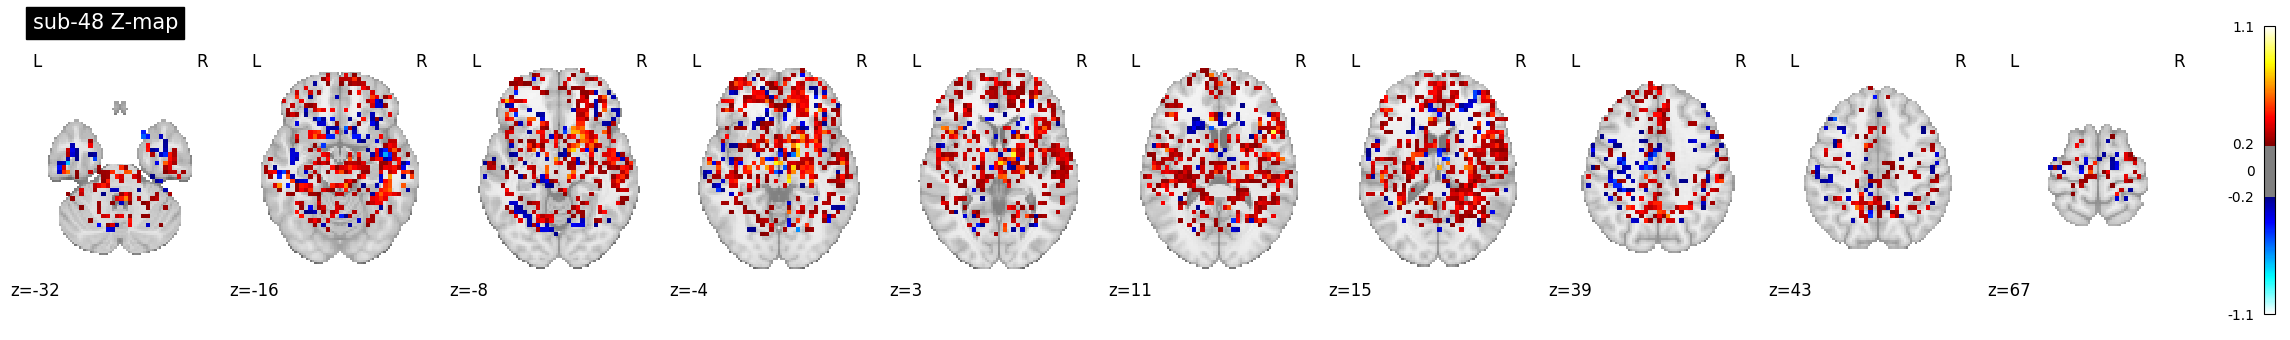

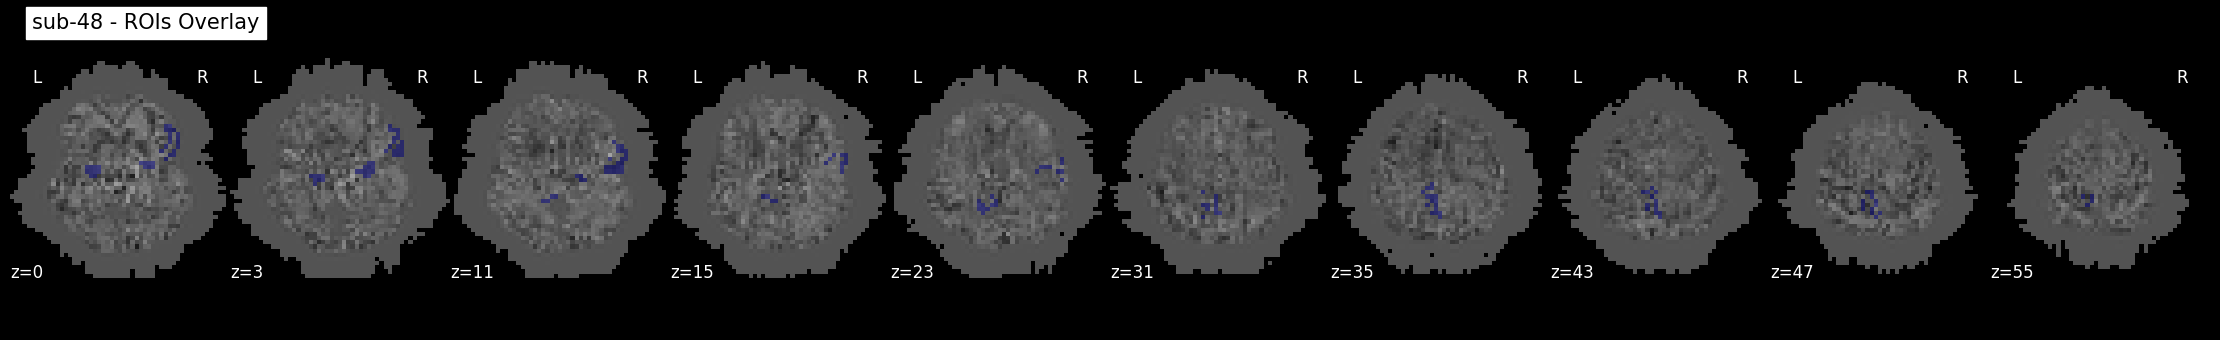

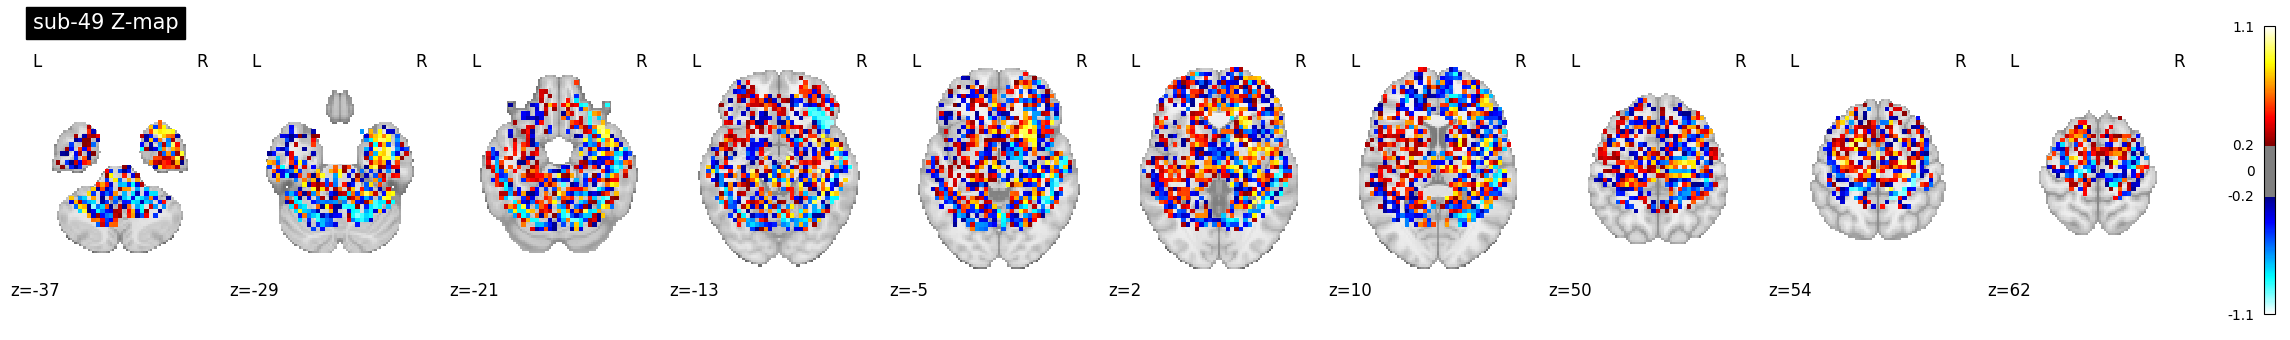

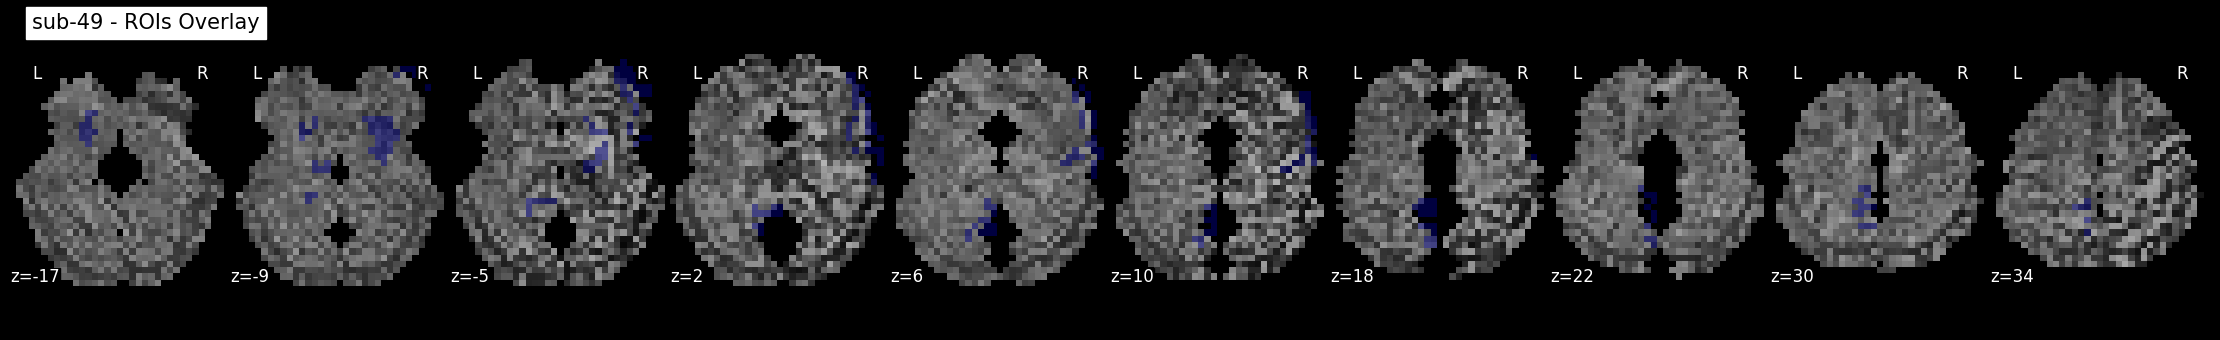

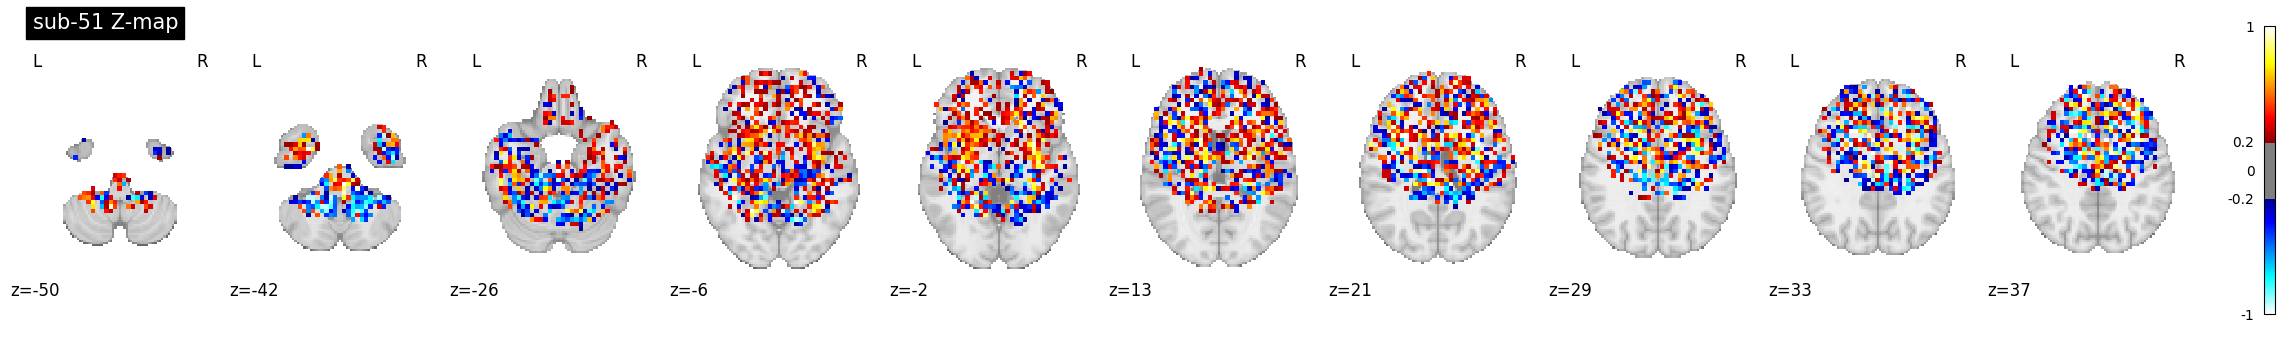

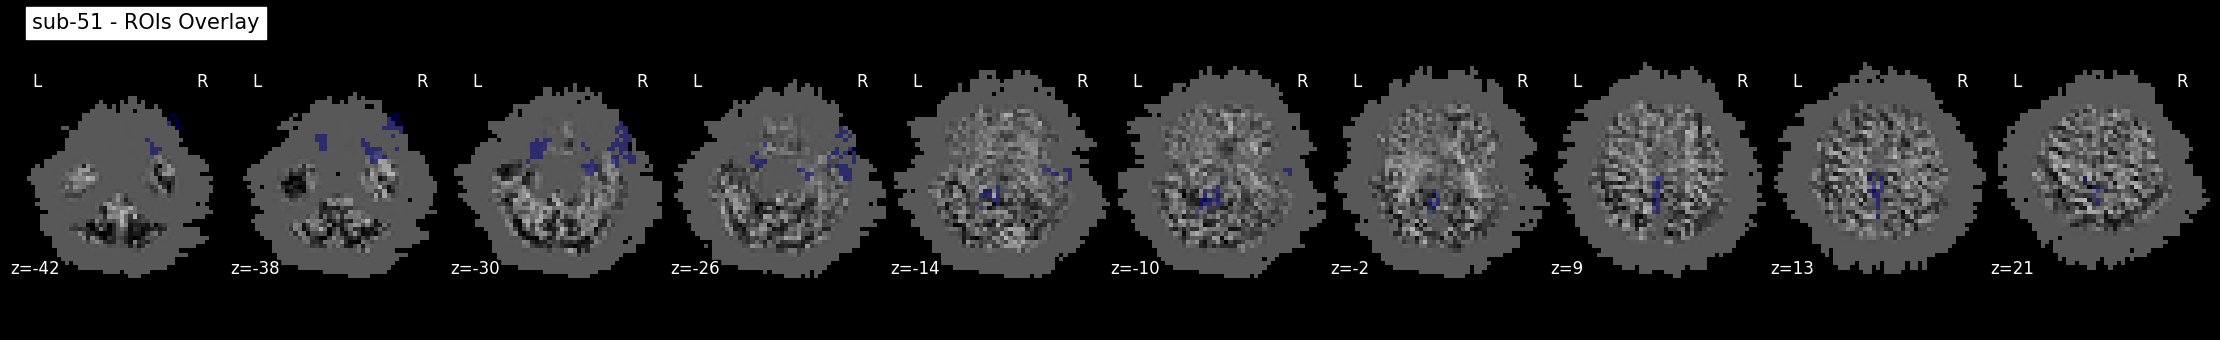

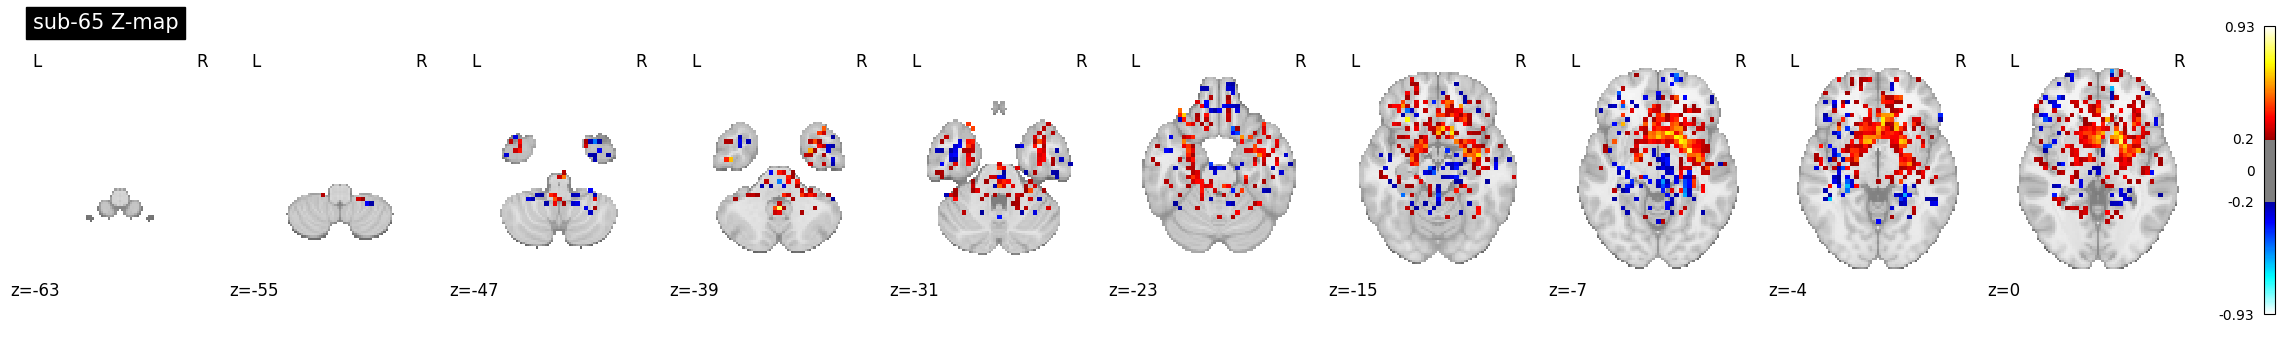

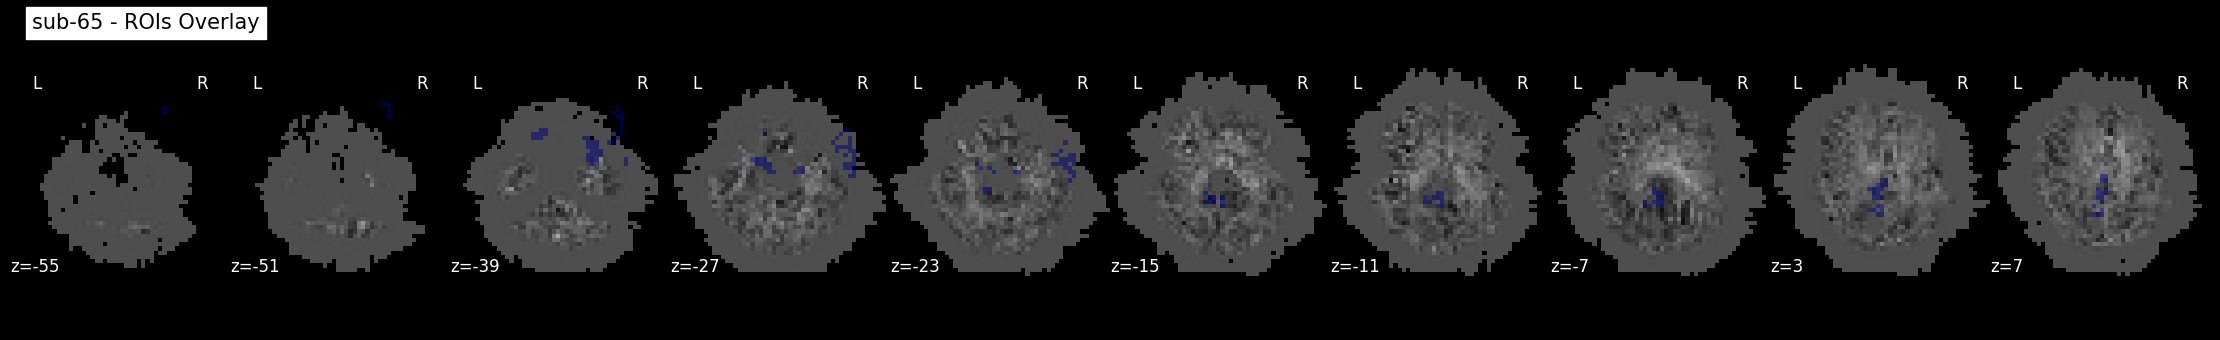

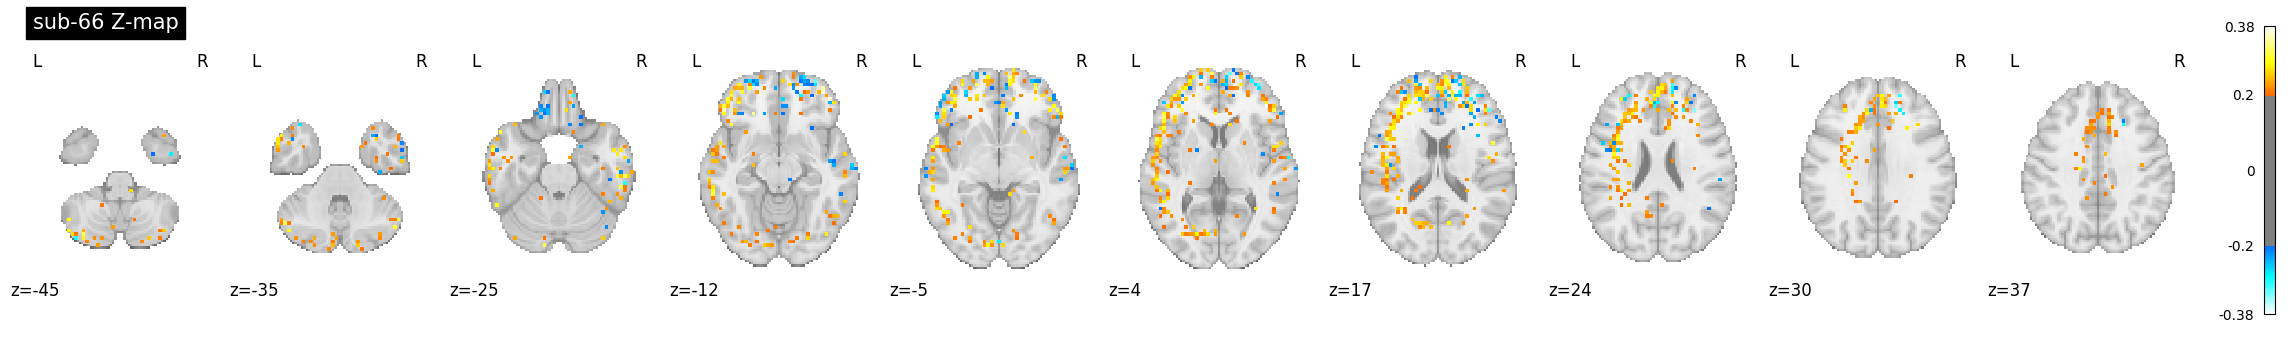

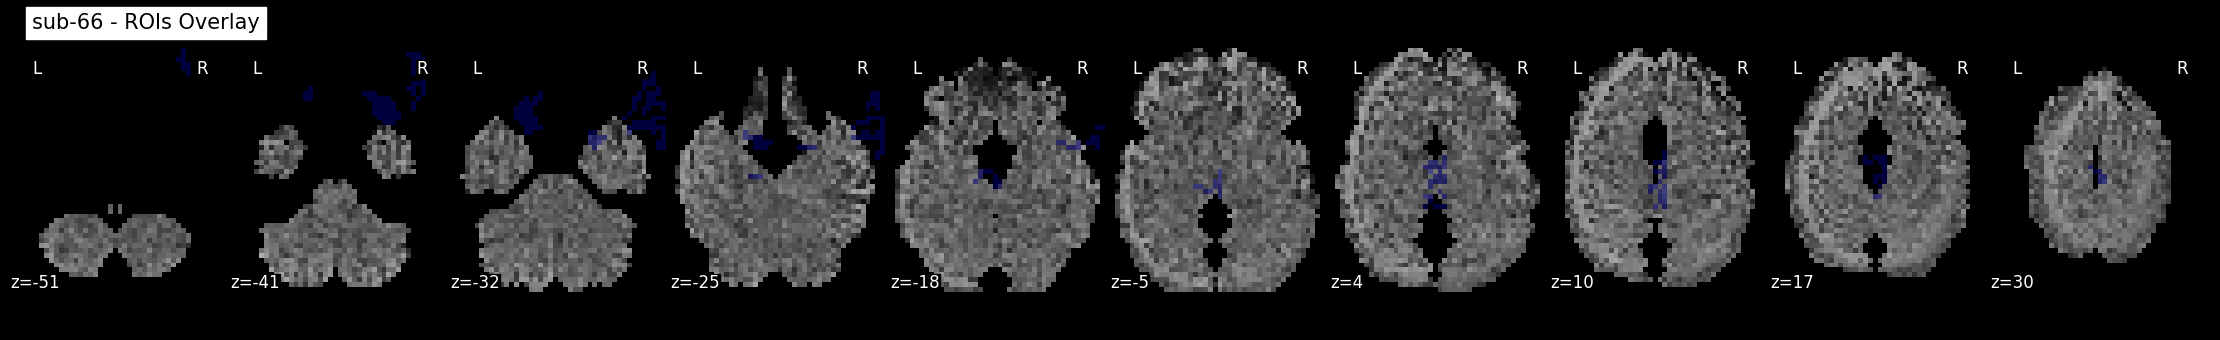

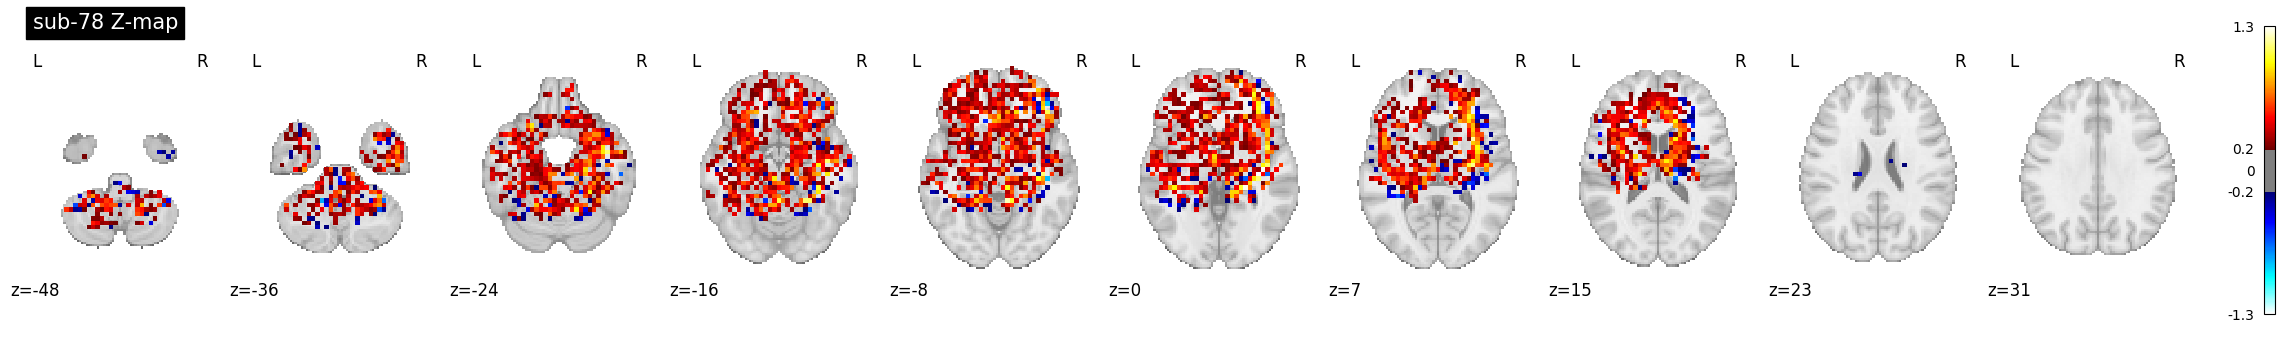

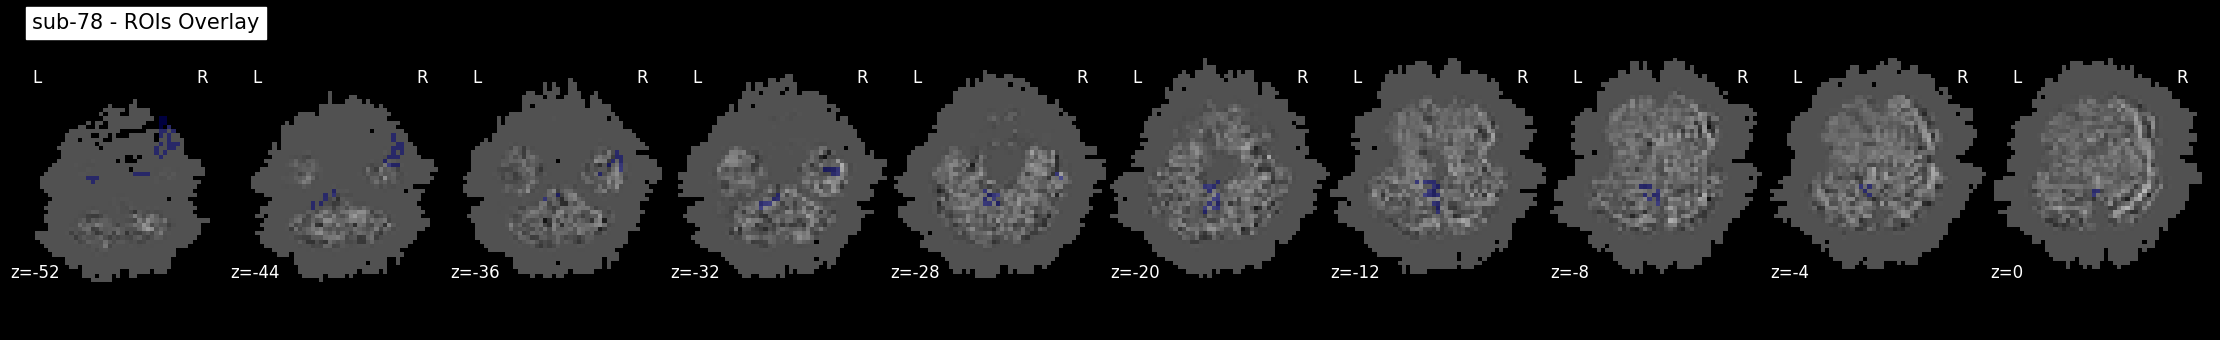

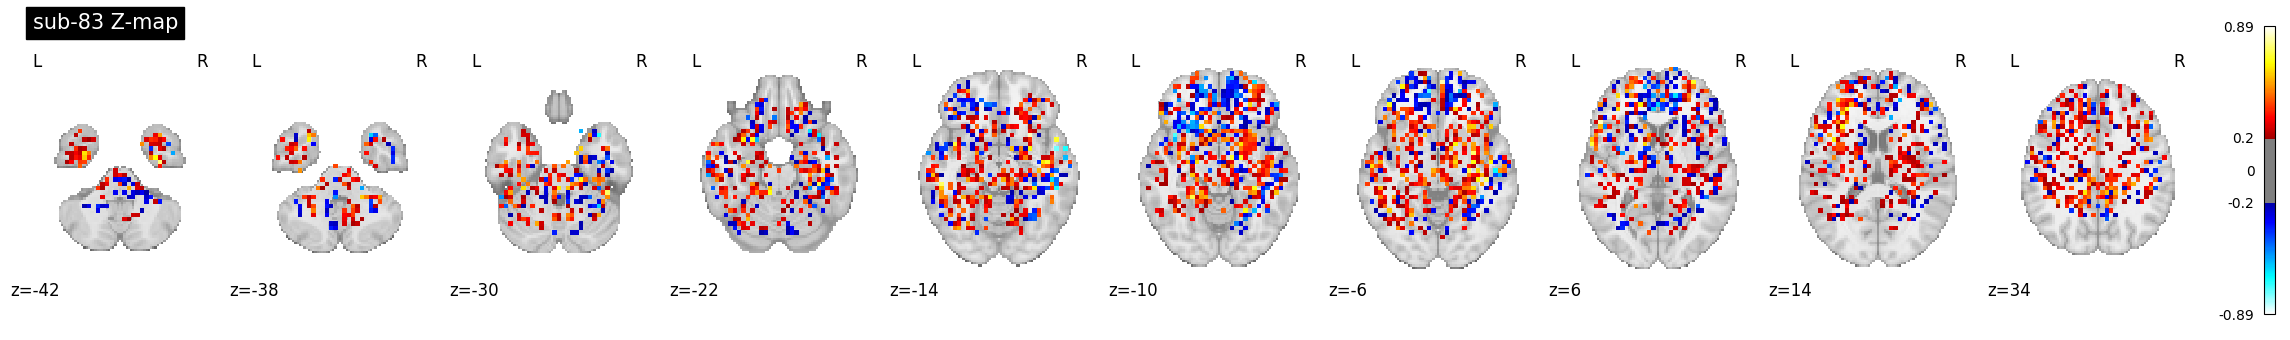

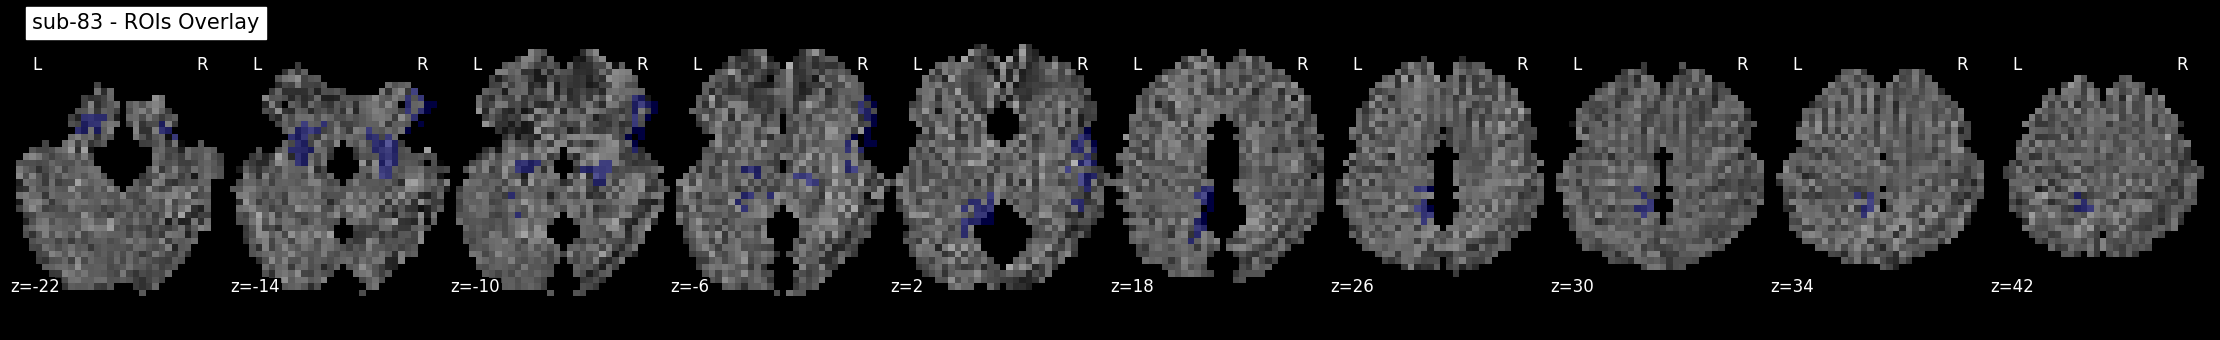

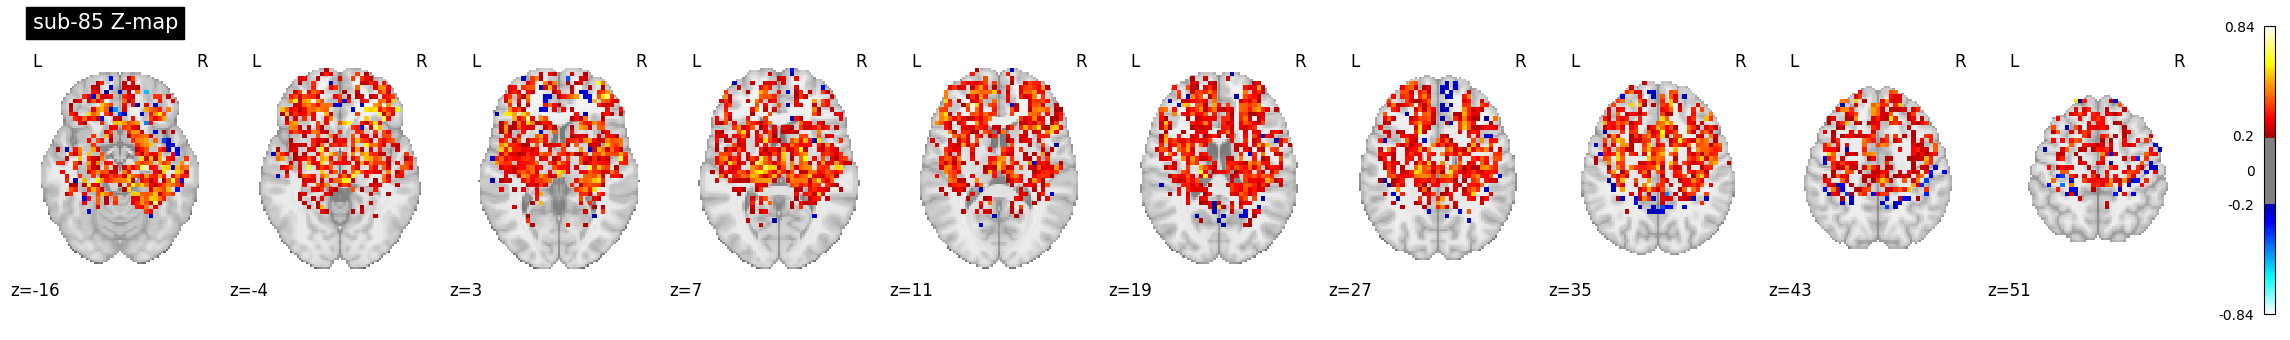

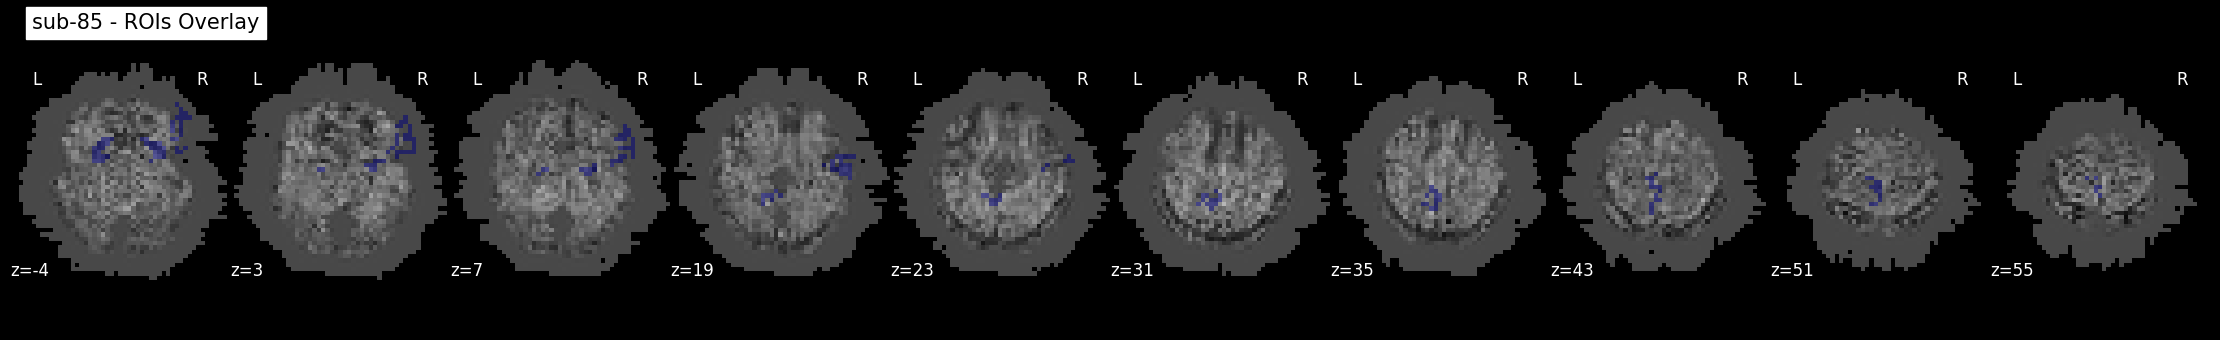

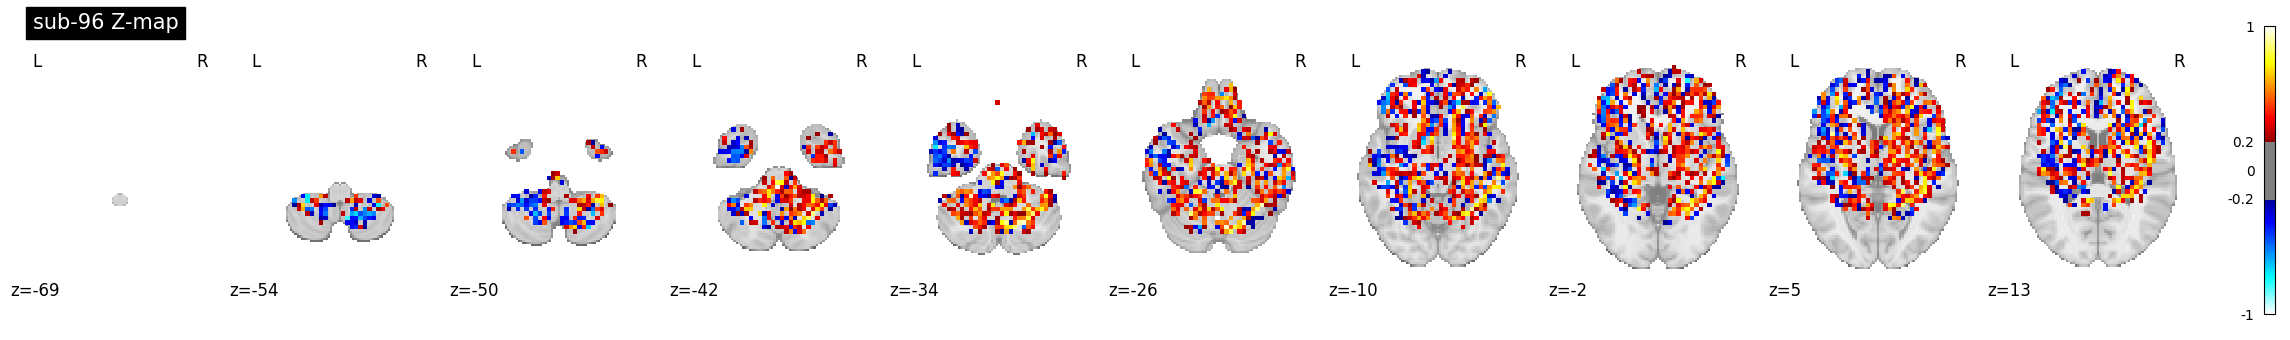

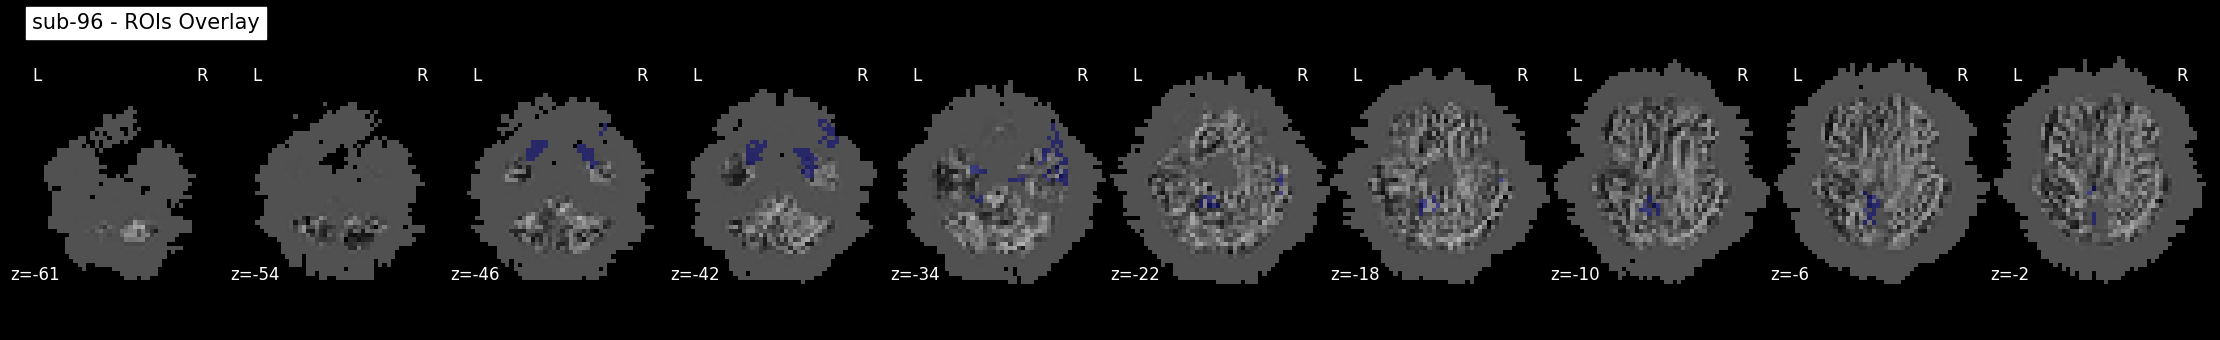

In [ ]:
import os
import nibabel as nib
import numpy as np
from nilearn import plotting, image

# Folder paths
zmap_folder = "/content/zmaps"
aparc_folder = "/content/aparc_segmentations"

# ROI labels to visualize (Alzheimer's-related)
roi_labels_to_plot = {
    17: "L_Hippocampus",
    53: "R_Hippocampus",
    2030: "R_PCC",
    1025: "L_Precuneus"
}

# Loop through each subject’s z-map
for fname in sorted(os.listdir(zmap_folder)):
    if not fname.endswith(".nii.gz"):
        continue

    subject_id = fname.split("_")[0]
    zmap_path = os.path.join(zmap_folder, fname)
    aparc_path = os.path.join(aparc_folder, f"{subject_id}_aparc+aseg.nii.gz")

    if not os.path.exists(aparc_path):
        print(f"❌ Missing aparc for {subject_id}, skipping...")
        continue

    print(f"🧠 Validating: {subject_id}")

    # Load z-map and aparc, then resample
    z_img = nib.load(zmap_path)
    aparc_img = nib.load(aparc_path)
    aparc_resampled = image.resample_to_img(aparc_img, z_img, interpolation='nearest')
    aparc_data = aparc_resampled.get_fdata()

    # Create combined ROI mask
    combined_mask_data = np.zeros_like(aparc_data)
    for label_val in roi_labels_to_plot.keys():
        combined_mask_data[aparc_data == label_val] = 1
    combined_mask_img = nib.Nifti1Image(combined_mask_data, z_img.affine)

    # Plot
    plotting.plot_stat_map(
        z_img,
        threshold=0.2,
        display_mode='z',
        cut_coords=10,
        title=f"{subject_id} Z-map"
    )

    plotting.plot_roi(
        combined_mask_img,
        bg_img=z_img,
        display_mode='z',
        cut_coords=10,
        title=f"{subject_id} - ROIs Overlay",
        alpha=0.5
    )


In [ ]:
import pandas as pd
from scipy.stats import ttest_ind

# Load z-score table
df = pd.read_csv("roi_zscores_diagnoses.csv")

# Separate groups
group_AD = df[df['Diagnoses'] == 0]
group_control = df[df['Diagnoses'] == 1]

# Drop subject id and diagnosis since those are just labels
roi_columns = [col for col in df.columns if col not in ['subject_id', 'diagnosis']]

# Run t-tests
print("📊 ROI-wise T-tests (AD vs Control):")
for roi in roi_columns:
    t_stat, p_val = ttest_ind(group_AD[roi], group_control[roi], nan_policy='omit')
    print(f"{roi:<20} t = {t_stat:.3f}, p = {p_val:.4f}")


📊 ROI-wise T-tests (AD vs Control):
Diagnoses            t = -inf, p = 0.0000
L_Hippocampus        t = 1.127, p = 0.2725
R_Hippocampus        t = 0.658, p = 0.5179
L_Entorhinal         t = -1.020, p = 0.3195
R_Entorhinal         t = -0.447, p = 0.6594
L_InferiorParietal   t = 1.758, p = 0.0934
R_InferiorParietal   t = 0.017, p = 0.9865
L_Precuneus          t = 0.662, p = 0.5154
R_Precuneus          t = 0.126, p = 0.9006
R_PCC                t = -0.388, p = 0.7016
L_SuperiorTemporal   t = 0.141, p = 0.8891
L_MedialOFC          t = 0.471, p = 0.6424
R_MedialOFC          t = -0.045, p = 0.9643


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:573: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


All p-values are greater than 0.05, indicating that zscores do not significantly differ between AD and control groups.

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# Load z-score table
df = pd.read_csv("roi_zscores_diagnoses.csv")

# Separate into groups
group_AD = df[df['Diagnoses'] == 0]
group_control = df[df['Diagnoses'] == 1]

# ROIs to analyze
roi_columns = [col for col in df.columns if col not in ['subject_id', 'Diagnoses']]

# Store results
bootstrap_results = []

# Number of bootstrap samples
n_bootstrap = 10000

for roi in roi_columns:
    ad_vals = group_AD[roi].dropna().values
    ctrl_vals = group_control[roi].dropna().values

    # Skip if either group has < 2 values to have more reliable regions for comparison after removing the NaN values
    if len(ad_vals) < 2 or len(ctrl_vals) < 2:
        continue

    # Generate bootstrap distribution of mean differences
    boot_diffs = []
    for _ in range(n_bootstrap):
        ad_sample = np.random.choice(ad_vals, size=len(ad_vals), replace=True)
        ctrl_sample = np.random.choice(ctrl_vals, size=len(ctrl_vals), replace=True)
        diff = np.mean(ad_sample) - np.mean(ctrl_sample)
        boot_diffs.append(diff)

    # Compute p-value (two-tailed)
    boot_diffs = np.array(boot_diffs)
    observed_diff = np.mean(ad_vals) - np.mean(ctrl_vals)
    p_value = np.mean(np.abs(boot_diffs) >= np.abs(observed_diff))

    # CI
    ci_lower = np.percentile(boot_diffs, 2.5)
    ci_upper = np.percentile(boot_diffs, 97.5)

    bootstrap_results.append({
        "ROI": roi,
        "Observed_Diff": observed_diff,
        "p_value": p_value,
        "95% CI Lower": ci_lower,
        "95% CI Upper": ci_upper
    })

# Display results
bootstrap_df = pd.DataFrame(bootstrap_results)
bootstrap_df = bootstrap_df.sort_values("p_value")
print(bootstrap_df.to_string(index=False))


               ROI  Observed_Diff  p_value  95% CI Lower  95% CI Upper
      L_Entorhinal      -0.038546   0.4725     -0.101514      0.010501
L_InferiorParietal       0.038917   0.5061     -0.005989      0.080196
     L_Hippocampus       0.065873   0.5153     -0.041181      0.171081
     R_Hippocampus       0.039714   0.5571     -0.064428      0.141499
      R_Entorhinal      -0.015432   0.5888     -0.074852      0.031367
       L_Precuneus       0.043051   0.5960     -0.077997      0.150930
             R_PCC      -0.013396   0.6226     -0.073774      0.030990
       L_MedialOFC       0.022668   0.6632     -0.064773      0.113712
L_SuperiorTemporal       0.009044   0.8691     -0.107337      0.093302
       R_Precuneus       0.009575   0.8839     -0.124782      0.128949
       R_MedialOFC      -0.002240   0.9570     -0.089850      0.080606
R_InferiorParietal       0.000551   0.9860     -0.058419      0.054524


With bootstrapping no significant difference is observed in evaluating the zscores for hippocampul activity in relation to functional connectivity in resting state.